# Chapter 53. Deep Learning in Depth

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch53-deep-learning-in-depth.md`.

# Chapter 53. Deep Learning in Depth

*Part 6 — Production ML, Generative AI & MLOps*

> **Chapter at a glance**
>
> **You will learn to:** describe a neural network as a stack of very simple parts · follow one training step by hand, from forward pass to updated weights, and check it with a nudge · see what an optimizer such as Adam does differently from plain gradient descent · use the techniques that make training work (feature scaling, weight decay, initialization, batch normalization, dropout, learning-rate schedules, early stopping) · say what convolution and pooling do to an image, by computing them · build and judge a defect-detection model for Riverstone's moulding line, choosing its threshold from the cost of each kind of mistake, then let PyTorch learn the kernels · work through a transformer's attention step by step on four tokens · explain quantization, pruning, and distillation, and measure what quantization costs and saves · and say when deep learning is the wrong tool.
>
> **Before you start:** Chapter 35 (vectors, matrix products, derivatives and gradient descent, cross-entropy), Chapter 36 (train/test splits, cross-validation, leakage), Chapter 37 (linear and logistic regression, ridge, gradient boosting, overfitting), Chapter 39 (confusion matrix, precision and recall, choosing a threshold by cost), Chapter 41 (tokens and word embeddings), Chapter 43 (a first look at deep learning: neurons, the chain rule, PyTorch, a small CNN). Helpful: Chapter 22's regression basics (section 22.10), Chapter 33 (Big-O).
>
> **Time needed:** 17–20 hours, spread over three weeks, in three sittings: sections 53.0–53.3 (setup, a training step by hand, and the techniques), about 6 hours; sections 53.4–53.6 (convolution and the defect project), about 6 hours; sections 53.7–53.10 and the project, about 5 hours, plus the exercises.
>
> **Tools:** Python 3 with NumPy, scikit-learn (installed in Chapter 35) and PyTorch (installed in Chapter 43, section 43.0), plus matplotlib for one answer. Nothing new to install. Almost every calculation runs on a laptop CPU in seconds; building the defect features takes about a minute (section 53.6), so they are saved once. No GPU, no downloads, and no accounts.
>
> **Practice data:** `generate_defect_images.py` in `companion/ch53/` builds 6,000 images of moulded lids on Riverstone's conveyor, 7.9% of them defective, with three defect types (section 53.0). Fixed seed, so your numbers match the book's.

---

## Why this matters

Deep learning is the engine behind the things your business has started asking for: reading a photograph of a part and saying whether it's good, reading an email and extracting the order, answering a question from a manual. Chapters 54 to 58 build those applications. This chapter is what's inside them.

You don't need to be able to derive backpropagation to do that work well. You do need to be able to:

- **Say what the model is actually doing**, when a manager asks why it flagged a good part.
- **Recognize the failure modes**: a model that predicts the majority class and scores 92% accuracy, a model that learned the lighting rather than the defect, a model that works in the lab and not on the line.
- **Choose the operating point.** A defect detector's threshold is a business decision about the cost of a missed defect against the cost of a false alarm, and the data scientist is the only person in the room who can price it.
- **Read the vocabulary** in papers, vendor decks, and interviews: layers, activations, gradients, attention, quantization.

This chapter builds all of that from arithmetic you can check with a calculator.

---

## In plain English

**A neural network is a long chain of small, dumb decisions, tuned by trial and error.**

Picture a factory line of inspectors, each with one very simple rule. The first looks at raw pixels and reports things like "it's brighter here than there". The second takes those reports and says "that pattern looks like an edge". The third: "those edges form a ring". The last one says "ring present, no hole: good part".

Nobody wrote those rules. The line starts with every inspector guessing at random, and after each part the factory is told whether it got the answer right. The blame is then passed backwards down the line: each inspector nudges their rule a little in the direction that would have made the answer better. That's **backpropagation**, and the size of the nudge is the **learning rate**.

Do that thousands to millions of times and the early inspectors end up noticing edges, the middle ones shapes, and the last ones the decision. **Depth** is what gives the chain its power: simple parts, stacked, can express complicated things.

Two more ideas from this chapter fit the same picture. **Convolution** is one inspector sliding the same small rule across the whole image, so a scratch is found wherever it appears. **Attention**, the idea behind every large language model, is an inspector who, before deciding about one word, looks back at every other word and weighs how much each one matters.

---

## 53.0 Setting up

### The practice images

Nothing new needs installing: NumPy and scikit-learn came in Chapters 18 and 35, and PyTorch in Chapter 43 (section 43.0). What you do need is the practice data. Open a terminal, activate the book's virtual environment (Chapter 17, section 17.0; terminal basics are in Chapter 26, section 26.0), and go to the chapter's companion folder:

**The chapter's output:**

```
# terminal
$ cd companion/ch53
$ python generate_defect_images.py
6,000 images of 32x32 pixels
defective 476 (7.9%) · good 5524 · scratch 162 · void 157 · short_shot 157
wrote defect_data/images.npy, defect_data/labels.npy, defect_data/defect_types.npy
```

- `cd companion/ch53` moves into the folder that holds the script.
- `python generate_defect_images.py` draws 6,000 top-down pictures of moulded lids, 32 × 32 pixels each, and saves them in a new folder, `defect_data`. It takes about a second. The script uses a fixed random seed (53), so everyone gets exactly the same images, and the three lines it prints are its confirmation: if yours match, the data is right.

Start Jupyter from this folder (Chapter 17, section 17.0), open a new notebook, and run every cell in this chapter in order: each uses names made by the cells before it.

### Loading them: `.npy` files

The script saved three **`.npy` files**. That's NumPy's own file format: one array per file, stored exactly, with its shape and number type, so it loads back as the same array. `np.save("name.npy", array)` writes one, and `np.load("name.npy")` reads it:

In [1]:
import numpy as np

images = np.load("defect_data/images.npy")
labels = np.load("defect_data/labels.npy")
print(images.shape, images.dtype)
print(labels.shape, labels.dtype, labels[:12])

(6000, 32, 32) float32
(6000,) int8 [0 0 0 0 0 0 0 0 0 0 0 0]


- `np.load("defect_data/images.npy")` reads the file back into an array. The path is relative to the notebook's folder, which is why the notebook lives in `companion/ch53`.
- `images.shape` is (6000, 32, 32): 6,000 images, each a grid of 32 rows and 32 columns of brightness values. Its type is `float32`, the 32-bit numbers of Chapter 43 (section 43.0).
- `labels` holds one number per image: 1 for a defective part, 0 for a good one. `labels[:12]` shows the first twelve.

A CSV would work for the labels, but not for a stack of 6,000 grids, and it would store every number as text. `.npy` is the usual way to keep arrays between notebooks. Section 53.6 saves one of its own.

---

## 53.1 From regression to a network

Chapter 43 showed that a neuron is logistic regression with a bend (section 43.1), trained small networks in PyTorch, and ran a tiny convolutional network on digits. This chapter opens the box: one full training step entirely by hand, the techniques that make training work, why convolution and attention are shaped the way they are, and how to shrink a model.

A quick reminder first. A **neuron** computes the same weighted sum as linear regression (Chapter 22, section 22.10; Chapter 37, section 37.1):

*prediction = w*<sub>1</sub>*x*<sub>1</sub> *+ w*<sub>2</sub>*x*<sub>2</sub> *+ … + b*

and passes the result through an **activation function** that bends it (Chapter 43, section 43.1). Without the bend, stacking layers would be pointless, because a chain of linear functions is just another linear function. With it, a stack can describe curves, corners, and combinations. Here is one neuron with ReLU, in NumPy:

In [2]:
def relu(x):
    """The most common activation: keep positives, flatten negatives to zero."""
    return np.maximum(0, x)

weights = np.array([0.6, -0.4])        # one weight per input
bias = 0.1
inputs = np.array([2.0, 3.0])

weighted_sum = float(inputs @ weights + bias)
output = float(relu(weighted_sum))
print(f"inputs        {inputs}")
print(f"weighted sum  {weighted_sum:.2f}   (2.0*0.6 + 3.0*-0.4 + 0.1)")
print(f"after ReLU    {output:.2f}")

negative_sum = float(np.array([1.0, 3.0]) @ weights + bias)
print(f"inputs [1. 3.]: weighted sum {negative_sum:.2f}, after ReLU {float(relu(negative_sum)):.2f}")

inputs        [2. 3.]
weighted sum  0.10   (2.0*0.6 + 3.0*-0.4 + 0.1)
after ReLU    0.10
inputs [1. 3.]: weighted sum -0.50, after ReLU 0.00


**Line by line:**

- `def relu(x):` defines the activation. `np.maximum(0, x)` compares each element of `x` with 0 and keeps the larger, so −2.3 becomes 0 and 1.7 stays 1.7. Chapter 43 wrote ReLU with Python's `max(0.0, z)`, which works on one number; `np.maximum` works on a whole array at once, which a layer needs.
- `weights = np.array([0.6, -0.4])` is the neuron's two weights, one per input. These are the numbers training will change.
- `bias = 0.1` shifts the result up or down regardless of the inputs, exactly like the intercept in regression.
- `inputs @ weights` is the **dot product** (Chapter 35, section 35.2): `2.0*0.6 + 3.0*-0.4`. For two one-dimensional arrays, `@` is the sum of the products.
- `float(...)` converts NumPy's result to an ordinary Python number. With the `:.2f` format it prints 0.10 either way; it matters when you print or store the value on its own, where NumPy 2 labels its own number type and shows every digit: `np.float64(0.0999999999999999)`, the same kind of rounding tail Chapter 43 (section 43.0) met in 32-bit numbers.
- The last two lines show the bend: inputs [1.0, 3.0] give a weighted sum of 0.6 − 1.2 + 0.1 = −0.5, and ReLU turns it into 0. That flattening is what lets a stack of neurons make decisions rather than straight lines.

**Layers.** You met layers in Chapter 43 (section 43.2): a **layer** is a row of neurons all looking at the same inputs, and a network is layers in sequence, the outputs of one becoming the inputs of the next. The terms, once more:

| Term | Means |
|---|---|
| **Input layer** | the raw numbers: 1,024 pixel values for a 32×32 image |
| **Hidden layer** | any layer between input and output; "deep" means more than one |
| **Output layer** | the answer: one number for "probability this part is defective", ten for "which digit is this" |
| **Parameters** | every weight and bias, all learned. A 1,024 → 64 → 1 network has 1,024×64 + 64 + 64 + 1 = **65,665** of them |

That last number is worth holding on to. A model is a big pile of numbers, and training is the search for a good pile.

---

## 53.2 Training, worked by hand

Training repeats four steps: **predict**, **measure the error**, **work out which way each weight should move**, **move it a little**. Chapter 43 (sections 43.3 and 43.4) did the first three by hand for one example. Here are all four, including the update, on a network small enough to check with a calculator: two inputs, two hidden neurons, one output.

Two things differ from Chapter 43, on purpose. The hidden layer uses ReLU instead of tanh, because ReLU is what real hidden layers use (Chapter 43, section 43.1). And Chapter 43 used a sigmoid output with log loss for a yes/no answer; here the output is a plain number with **squared error**, because its derivative is the easiest to follow by hand. The backward-pass pattern is identical.

In [3]:
x = np.array([1.0, 2.0])                 # one training example: two features
y_true = 1.0                             # the right answer for it

W1 = np.array([[0.5, -0.3],              # hidden layer: 2 inputs -> 2 neurons
               [0.8,  0.2]])
b1 = np.array([0.0, 0.1])
W2 = np.array([0.7, -0.5])               # output layer: 2 hidden -> 1 output
b2 = 0.05

# --- forward pass: compute the prediction
z1 = x @ W1 + b1                         # weighted sums for the two hidden neurons
a1 = np.maximum(0, z1)                   # ReLU
z2 = float(a1 @ W2 + b2)                 # weighted sum for the output neuron
loss = (z2 - y_true) ** 2                # squared error: how wrong we were

print(f"hidden sums z1 = {np.round(z1, 3)}")
print(f"after ReLU  a1 = {np.round(a1, 3)}")
print(f"prediction  z2 = {z2:.3f}   true = {y_true}")
print(f"loss           = {loss:.3f}")

hidden sums z1 = [2.1 0.2]
after ReLU  a1 = [2.1 0.2]
prediction  z2 = 1.420   true = 1.0
loss           = 0.176


**Line by line:**

- `x` is one example, and `y_true` the answer we want. Real training uses thousands; the arithmetic is identical.
- `W1` is a 2×2 matrix: **row i, column j** is the weight from input *i* to hidden neuron *j*. (Chapter 43 stored one row per neuron and wrote `W1 @ x`; here it's one row per input and `x @ W1`. Same numbers, arranged the other way round.) `b1` holds one bias per hidden neuron.
- `x @ W1` multiplies the input vector by the matrix, giving one weighted sum per hidden neuron: for neuron 0 that's `1.0*0.5 + 2.0*0.8 = 2.1`, then `+ b1[0] = 0.0`, so 2.1.
- `np.maximum(0, z1)` applies ReLU to both hidden sums at once. Neuron 1's sum is 1.0 × (−0.3) + 2.0 × 0.2 = 0.1, plus its bias 0.1 = 0.2, which is positive, so it survives ReLU; nothing is negative here, so `a1` equals `z1` this time.
- `a1 @ W2 + b2` is the output neuron. `float(...)` again gives a plain Python number.
- `(z2 - y_true) ** 2` is the **loss**: the squared difference between prediction and truth. Squaring makes every error positive and punishes big misses more than small ones. Training exists to make this number smaller.

Our target is a number, so squared error fits. For a yes/no target the output goes through a sigmoid and the loss is log loss (Chapter 35, section 35.9; Chapter 43, section 43.4); the backward pass then starts from (prediction − truth) instead of 2 × (prediction − truth), and everything after that is the same.

### The chain rule, with this network's numbers

**The gradient of the loss with respect to a weight answers one question: if I increase this weight by a tiny amount, does the loss go up or down, and how fast?** Chapter 43 (section 43.4) worked it out with the **chain rule**: if *a* changes *b*, and *b* changes *c*, then how much *a* changes *c* = (how much *a* changes *b*) × (how much *b* changes *c*).

Here it is for one weight of this network, `W2[0]`:

- The loss changes 0.84 per unit of `z2`: the derivative of (*z*₂ − *y*)² is 2 × (*z*₂ − *y*) = 2 × 0.42 (the same derivative as Chapter 35, section 35.4, for one example).
- `z2` changes 2.1 per unit of `W2[0]`, because `W2[0]` is multiplied by `a1[0]` = 2.1.
- So the loss changes 0.84 × 2.1 = **1.764** per unit of `W2[0]`.

The backward pass does that for every weight, starting at the loss and reusing each result for the layer before it:

In [4]:
# --- backward pass: how should each weight change?
dloss_dz2 = 2 * (z2 - y_true)            # derivative of (z2 - y)^2 with respect to z2
dW2 = dloss_dz2 * a1                     # each output weight is blamed in proportion to its input
db2 = dloss_dz2

da1 = dloss_dz2 * W2                     # blame passed back to the hidden activations
dz1 = da1 * (z1 > 0)                     # ReLU passes blame only where it was active
dW1 = np.outer(x, dz1)                   # each hidden weight is blamed in proportion to its input
db1 = dz1

print(f"dloss/dz2 = {dloss_dz2:.3f}")
print(f"dW2       = {np.round(dW2, 3)}      db2 = {db2:.3f}")
print(f"dz1       = {np.round(dz1, 3)}")
print(f"dW1       =\n{np.round(dW1, 3)}")

dloss/dz2 = 0.840
dW2       = [1.764 0.168]      db2 = 0.840
dz1       = [ 0.588 -0.42 ]
dW1       =
[[ 0.588 -0.42 ]
 [ 1.176 -0.84 ]]


**Line by line:**

- `dloss_dz2 = 2 * (z2 - y_true)`: differentiating `(z2 − y)²` gives `2(z2 − y)`, the same derivative as Chapter 35 (section 35.4), for one example. It's positive when we predicted too high, so the update will push the prediction down.
- `dW2 = dloss_dz2 * a1`: the output is `a1[0]*W2[0] + a1[1]*W2[1] + b2`, so changing `W2[0]` changes the output in proportion to `a1[0]`. That's the chain rule above: 0.84 × 2.1 = 1.764. A weight whose input was large gets most of the blame.
- `db2 = dloss_dz2`: the bias is added directly, so its share is the error itself.
- `da1 = dloss_dz2 * W2` sends the blame backwards: a hidden neuron connected by a large weight contributed more, so it receives more.
- `dz1 = da1 * (z1 > 0)` is ReLU's derivative: 1 where the neuron was active, 0 where it wasn't (Chapter 43, section 43.1). `(z1 > 0)` is a boolean array, which NumPy treats as 1 and 0: a neuron that was switched off contributed nothing, so it gets no blame. (This is why "dead" ReLU neurons, permanently negative, stop learning.)
- `np.outer(x, dz1)` builds the 2×2 matrix of blame for `W1`: element (i, j) is `x[i] * dz1[j]`, the same "in proportion to your input" rule one layer down. `np.outer` multiplies every element of the first array by every element of the second.

### Checking with a nudge

Chapter 43 (section 43.4) checked its gradients by nudging a weight and measuring how far the loss moved. Do the same for `W2[0]`: raise it by a millionth, recompute the loss, and divide the change by the nudge. NumPy's numbers are 64-bit, so the rounding trouble Chapter 43 met in 32-bit numbers doesn't arise.

In [5]:
def loss_with(W2_trial):
    """The forward pass again, with a different W2."""
    hidden = np.maximum(0, x @ W1 + b1)
    return (float(hidden @ W2_trial + b2) - y_true) ** 2

eps = 1e-6
W2_nudged = W2.copy()
W2_nudged[0] += eps
numerical = (loss_with(W2_nudged) - loss) / eps
print(f"numerical {numerical:.4f} vs backprop {dW2[0]:.4f}")

numerical 1.7640 vs backprop 1.7640


- `loss_with` repeats the forward pass with whatever output weights it's given, so only `W2` changes.
- `W2.copy()` makes a separate copy, so the real `W2` stays untouched; `W2_nudged[0] += eps` raises the first weight by `eps` = 0.000001.
- `(loss_with(W2_nudged) - loss) / eps` is the change in loss per unit of change in the weight: the slope, measured rather than derived.

The nudge and the backward pass agree. Now the update, which is one line per weight and the whole of **gradient descent**:

In [6]:
learning_rate = 0.05
W1_new = W1 - learning_rate * dW1
b1_new = b1 - learning_rate * db1
W2_new = W2 - learning_rate * dW2
b2_new = b2 - learning_rate * db2

z1n = np.maximum(0, x @ W1_new + b1_new)
z2n = float(z1n @ W2_new + b2_new)
print(f"prediction before {z2:.3f}, after one step {z2n:.3f}, target {y_true}")
print(f"loss       before {loss:.3f}, after one step {(z2n - y_true) ** 2:.3f}")

prediction before 1.420, after one step 1.019, target 1.0
loss       before 0.176, after one step 0.000


**Line by line:** each weight moves *against* its gradient, because the gradient points uphill and we want to go down. `learning_rate` decides how big the step is: too small and training crawls, too large and it overshoots and bounces (exercise 3 tries both). The last three lines run the forward pass again with the new weights. That is the entire algorithm. A real network does this with millions of weights and batches of examples, on a GPU, but every one of those steps is the arithmetic above.

![A left-to-right forward pass from inputs to loss, then an orange backward pass returning each gradient from right to left, then the update line showing the prediction moving from 1.420 to 1.019](figures/fig53-1-training-step.svg)

*Figure 53.1 — One training step, with section 53.2's numbers. Everything else is this, repeated.*

### Optimizers, one step by hand

The update above is plain gradient descent: every weight moves by learning rate × gradient. Real training almost always uses a smarter rule, an **optimizer**. Chapter 43 used **Adam** (`torch.optim.Adam`, section 43.5), and scikit-learn's neural network uses it by default. Here is what it does differently, on the simplest possible problem: minimise (*w* − 3)², starting from *w* = 0, where the gradient is 2(*w* − 3) = −6.

In [7]:
w = 0.0
gradient = 2 * (w - 3)              # slope of (w - 3)^2 at w = 0
lr = 0.1

plain_step = -lr * gradient
print(f"plain gradient descent: w moves by {plain_step:+.3f}, to {w + plain_step:.3f}")

beta1, beta2 = 0.9, 0.999
m = (1 - beta1) * gradient          # running average of gradients, starting from 0
v = (1 - beta2) * gradient ** 2     # running average of squared gradients, starting from 0
m_hat = m / (1 - beta1)             # correct for starting at 0 (first step)
v_hat = v / (1 - beta2)
adam_step = -lr * m_hat / (np.sqrt(v_hat) + 1e-8)
print(f"m = {m:.3f}, v = {v:.3f}, m_hat = {m_hat:.3f}, v_hat = {v_hat:.3f}")
print(f"Adam: w moves by {adam_step:+.3f}, to {w + adam_step:.3f}")

plain gradient descent: w moves by +0.600, to 0.600
m = -0.600, v = 0.036, m_hat = -6.000, v_hat = 36.000
Adam: w moves by +0.100, to 0.100


**Line by line:**

- `plain_step = -lr * gradient` is section 53.2's update: 0.1 × 6 = 0.6, so *w* jumps from 0 to 0.6.
- `beta1, beta2 = 0.9, 0.999` are Adam's two memory settings, and these are its usual defaults. Adam keeps two running averages from step to step: `m`, of recent gradients, and `v`, of recent *squared* gradients. Each new average is mostly the old one (90% or 99.9%) plus a little of the new gradient. Both start at 0, so on the first step `m` is 0.1 × (−6) = −0.6 and `v` is 0.001 × 36 = 0.036.
- `m_hat` and `v_hat` undo the pull towards 0 from that starting point: dividing by (1 − 0.9) and (1 − 0.999) gives back −6 and 36 on the first step.
- `adam_step = -lr * m_hat / (np.sqrt(v_hat) + 1e-8)` divides the average gradient by its typical size, √36 = 6, so the step is 0.1 × (−6) ÷ 6 = −0.1, moving *w* by +0.1. The tiny `1e-8` only prevents a division by zero.

**The lesson:** Adam divides by the gradient's typical size, so every weight moves roughly `lr` per step whatever the scale of its gradient. Change the gradient to 100 times larger and see:

In [8]:
for gradient in (-6.0, -600.0):
    m_hat = gradient                          # after bias correction, on the first step
    v_hat = gradient ** 2
    print(f"gradient {gradient:>7}: plain step {-lr * gradient:+8.3f}   "
          f"Adam step {-lr * m_hat / (np.sqrt(v_hat) + 1e-8):+.3f}")

gradient    -6.0: plain step   +0.600   Adam step +0.100
gradient  -600.0: plain step  +60.000   Adam step +0.100


- On the first step `m_hat` equals the gradient and `v_hat` its square, as the previous cell showed, so the loop uses them directly.

Plain gradient descent would leap 60 units on the large gradient; Adam still moves 0.1. That's why Adam needs far less learning-rate tuning, and why it's the usual default. (On the first step Adam moves by exactly the learning rate; try changing `lr` to 0.5 and both Adam steps become +0.500, while the plain steps grow five-fold.) A simpler relative, **momentum**, keeps only the running average `m` and steps along it, so steps don't zig-zag when the gradient keeps changing direction (`torch.optim.SGD(..., momentum=0.9)` in PyTorch).

**Vocabulary you now own:**

| Term | Means |
|---|---|
| **Forward pass** | computing the prediction from the inputs |
| **Loss function** | how wrong the prediction was: squared error for numbers, **cross-entropy** (log loss) for classification |
| **Gradient** | which way, and how fast, the loss changes if a weight changes |
| **Backpropagation** | computing every gradient by passing blame backwards through the layers, with the chain rule |
| **Gradient descent** | moving each weight a little against its gradient |
| **Learning rate** | the size of that step |
| **Optimizer** | the rule that turns gradients into weight changes: plain gradient descent, momentum, Adam |
| **Epoch** | one pass over the whole training set |
| **Batch** | the handful of examples used for one update (32 to 512 is typical). Chapter 43 used all rows at once (full batch); section 53.6's PyTorch model uses batches of 64 |

---

## 53.3 The techniques that make training work

Everything in this section exists because the basic loop above, run naively on a real network, trains badly. Each technique is a small change. Scaling is measured below, early stopping in section 53.6, and four more are worked by hand.

| Technique | What it does | Why it's needed |
|---|---|---|
| **Feature scaling** | put inputs on a similar scale (pixels ÷ 255, or subtract the mean and divide by the standard deviation) | a feature 1,000 times larger than another dominates the gradients |
| **Weight decay** (L2) | add a small penalty on large weights to the loss: the same idea as Chapter 37's ridge regression (section 37.2); scikit-learn calls it `alpha`, PyTorch `weight_decay` | keeps weights small, a guard against overfitting |
| **Sensible initialization** | start weights random but small, scaled to the layer's size: **He initialization** (for ReLU layers) draws them with standard deviation √(2 ÷ number of inputs); **Xavier initialization** (for tanh and sigmoid) uses a similar rule | all-zero weights learn nothing; too-large ones explode |
| **Batch normalization** | normalize each layer's outputs during training | keeps the signal in a sane range deep in the stack, so training is faster and less fussy |
| **Dropout** | randomly switch off a fraction of neurons each step | stops the network relying on any one path; a cheap, effective guard against overfitting |
| **Learning-rate schedule** | start larger, decay over time (step, cosine, or "reduce on plateau") | big steps early to make progress, small steps late to settle |
| **Early stopping** | stop when the validation score (or loss) stops improving | the cheapest regularizer there is |
| **Data augmentation** | train on flipped, rotated, slightly brighter copies of images | more effective variety without collecting more data |

### Scaling, measured

Two features that matter equally to the answer, but measured on very different scales. Before you run it, predict: which network does better, and by how much?

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(53)
n = 2000
feature_small = rng.normal(0, 1, n)                 # a sensible feature
feature_large = rng.normal(0, 1, n) * 1000          # a second, independent feature on a 1000x larger scale
y = (feature_small + feature_large / 1000 > 0).astype(int)
X = np.column_stack([feature_small, feature_large])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=53)

unscaled = MLPClassifier(hidden_layer_sizes=(16,), alpha=0.0001, max_iter=60, random_state=53).fit(Xtr, ytr)
scaled_tr = Xtr / Xtr.std(axis=0)
scaled_te = Xte / Xtr.std(axis=0)
scaled = MLPClassifier(hidden_layer_sizes=(16,), alpha=0.0001, max_iter=60, random_state=53).fit(scaled_tr, ytr)

print(f"unscaled inputs: test accuracy {unscaled.score(Xte, yte):.3f}, loss {unscaled.loss_:.4f}")
print(f"scaled inputs:   test accuracy {scaled.score(scaled_te, yte):.3f}, loss {scaled.loss_:.4f}")

unscaled inputs: test accuracy 0.930, loss 0.3293
scaled inputs:   test accuracy 0.987, loss 0.1390


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


**Line by line:**

- `rng = np.random.default_rng(53)` creates a random generator with a fixed seed, so these numbers are the same every time.
- `feature_small` and `feature_large` are two different random features that matter equally to the label: `y` is 1 when their sum, after undoing the ×1,000, is positive. But one is measured in units 1,000 times larger, like revenue in rupees next to a satisfaction score. `.astype(int)` turns True/False into 1/0, and `np.column_stack` puts the two features side by side as the two columns of `X`.
- `train_test_split(..., test_size=0.3, random_state=53)` holds back 30% of rows for testing, with a fixed seed so the split is reproducible (Chapter 36, section 36.3).
- `MLPClassifier` is scikit-learn's neural network (MLP stands for multi-layer perceptron, an old name for a fully connected network). `hidden_layer_sizes=(16,)` gives it one hidden layer of 16 ReLU neurons; `max_iter=60` allows at most 60 epochs; `random_state=53` fixes its random starting weights. It trains with Adam by default, on **mini-batches** of 200 rows (its `batch_size` setting), so each epoch is several small updates rather than one big one: Chapter 35's stochastic gradient descent.
- `alpha=0.0001` is **weight decay**, and it's scikit-learn's default: written out here so you can see it. Raise it and the weights are pushed harder towards zero, exactly as ridge's α did in Chapter 37.
- `.fit(Xtr, ytr)` runs the training loop of section 53.2, many times over.
- `Xtr / Xtr.std(axis=0)` divides each column by *its own* standard deviation, computed on the training data only. Using the training statistics on the test set is essential: computing them on the test set leaks information (Chapter 36, section 36.7, data leakage).
- `.score(...)` returns accuracy; `.loss_` is the final training loss (log loss).

Scaling alone lifts test accuracy by several points and halves the loss, with the same network and the same 60 epochs.

When you run that cell in Jupyter, a pink box also appears under the output, once for each model: `ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.` scikit-learn is warning that training stopped at `max_iter` before the loss settled. Here that's deliberate: we're comparing both models on the same short budget. Several networks in this chapter train on fixed budgets, so hide that one kind of warning from here on:

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

- `warnings` is Python's built-in module for warning messages. `warnings.filterwarnings("ignore", category=ConvergenceWarning)` hides only scikit-learn's "stopped before converging" message. Every other warning, and every error, still shows.

### Four more, by hand

The other techniques are small enough to work with the numbers you already have.

**Dropout.** During training, each hidden neuron is switched off at random with probability *p*, and the survivors are scaled up by 1 ÷ (1 − *p*). Take section 53.2's hidden outputs, `a1 = [2.1, 0.2]`, with *p* = 0.5:

In [11]:
p = 0.5
mask = np.array([1, 0])                  # this step: keep neuron 0, drop neuron 1
print("one training step: ", a1 * mask / (1 - p))

rng = np.random.default_rng(53)
masks = rng.random((10_000, 2)) > p      # 10,000 random masks, each neuron kept half the time
print("average of 10,000 steps:", np.round((a1 * masks / (1 - p)).mean(axis=0), 2))

one training step:  [4.2 0. ]
average of 10,000 steps: [2.08 0.2 ]


- `mask` is one step's choice: 1 keeps a neuron, 0 drops it. In real training it's drawn at random at every step; here it's written out so the arithmetic is visible: [2.1, 0.2] × [1, 0] ÷ 0.5 = [4.2, 0.0].
- `rng.random((10_000, 2)) > p` draws 10,000 random masks at once: `rng.random` gives numbers between 0 and 1, and `> p` keeps each neuron when its number is above 0.5, half the time. `10_000` is 10,000; Python ignores the underscore.
- `.mean(axis=0)` averages the 10,000 dropped-out versions, column by column.

The average comes back to about [2.1, 0.2]: the scaling keeps each neuron's average output the same, so nothing needs adjusting when dropout is **switched off at prediction time**. PyTorch's version is `nn.Dropout(p=0.5)`, the layer Chapter 43's project suggested trying.

**Batch normalization.** For each neuron, it takes the outputs across one batch, subtracts their mean, and divides by their standard deviation, so the next layer always sees numbers of a similar size. On a batch of four outputs:

In [12]:
outputs = np.array([2.0, 4.0, 6.0, 8.0])     # one neuron, four examples in the batch
mean, std = outputs.mean(), outputs.std()
print(f"mean {mean:.1f}, standard deviation {std:.3f}")
print("normalized:", np.round((outputs - mean) / std, 3))

mean 5.0, standard deviation 2.236
normalized: [-1.342 -0.447  0.447  1.342]


- `outputs.mean()` is 5 and `outputs.std()` is √5 = 2.236, the standard deviation of the four numbers (NumPy's default divides by *n*).
- `(outputs - mean) / std` centres the batch on 0 with a spread of 1.

The layer then multiplies by a learned scale and adds a learned shift (starting at 1 and 0), so the network can undo the normalization wherever that helps. PyTorch's version is `nn.BatchNorm1d` (and `nn.BatchNorm2d` after a convolution).

**He initialization.** For a layer with 1,024 inputs, He initialization draws the starting weights with standard deviation √(2 ÷ 1,024). Compare it with a careless standard deviation of 1, by pushing one random input through the layer and ReLU:

In [13]:
fan_in = 1024
he_std = np.sqrt(2 / fan_in)
x_in = rng.normal(0, 1, fan_in)                       # one input with 1,024 values
for name, std in (("std 1.0", 1.0), ("He", he_std)):
    W = rng.normal(0, std, (fan_in, 64))              # 1,024 inputs -> 64 neurons
    out = np.maximum(0, x_in @ W)
    print(f"{name:<8} weight std {W.std():.4f}   typical output size {np.sqrt((out ** 2).mean()):.2f}")

std 1.0  weight std 0.9983   typical output size 22.88
He       weight std 0.0444   typical output size 1.01


- `fan_in` is the number of inputs each neuron receives, the usual name for it. `he_std` is √(2 ÷ 1,024) = 0.0442.
- `rng.normal(0, std, (fan_in, 64))` draws a 1,024 × 64 weight matrix with the chosen standard deviation.
- `np.sqrt((out ** 2).mean())` measures the typical size of the 64 outputs after ReLU (the root of their average square).

With a standard deviation of 1, the outputs come out more than twenty times the size of the inputs, and a second layer like it would multiply them by twenty again: the signal explodes. He's rule keeps the typical output close to the input's size of 1, layer after layer. PyTorch's `nn.Linear` and `nn.Conv2d` already start from a rule of this kind, which is why Chapter 43 never had to think about it.

**A step schedule.** Start at a learning rate of 0.1 and halve it every 10 epochs:

In [14]:
for epoch in (0, 10, 20, 30):
    print(f"epoch {epoch:>2}: learning rate {0.1 * 0.5 ** (epoch // 10)}")

epoch  0: learning rate 0.1
epoch 10: learning rate 0.05
epoch 20: learning rate 0.025
epoch 30: learning rate 0.0125


- `epoch // 10` counts completed blocks of 10 epochs (`//` is whole-number division, Chapter 17), and `0.5 ** ...` halves the rate once per block.

PyTorch's version is `torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)`, called once per epoch.

---

## 53.4 The architectures, and what each is for

| Architecture | Built for | The idea in one line | Where you'll meet it |
|---|---|---|---|
| **MLP** (fully connected) | tables of features | every input connects to every neuron | small tabular models, and the last layers of bigger networks |
| **CNN** (convolutional) | images, and anything with local structure | slide the same small filter everywhere | defect detection, OCR, medical imaging |
| **RNN / LSTM** | sequences, read one step at a time | carry a memory forward through the sequence; an **LSTM** (long short-term memory) is an RNN with gates that decide what to remember and what to forget | older time-series and text models, still in some production systems |
| **Transformer** | sequences, read all at once | every position looks at every other and weighs it (section 53.7) | every large language model, and increasingly vision too |
| **Autoencoder** | compression and anomaly detection | squeeze the input through a narrow layer and rebuild it | spotting unusual sensor readings |
| **GAN / diffusion** | generating images | two networks compete, or noise is removed step by step | image generation (Chapter 54) |

This "transformer" is not the scikit-learn transformers of Chapter 36 (`ColumnTransformer` and friends); the name is a coincidence.

Two practical rules come out of that table. **The architecture encodes an assumption about your data**: a CNN assumes that what matters is local and can appear anywhere; a transformer assumes that any position may matter to any other. Choose the one whose assumption is true of your problem. And **for tables of numbers, gradient boosting usually wins** (Chapter 37, section 37.8; Chapter 43, section 43.5 saw it happen), which is section 53.10.

---

## 53.5 Convolution, step by step

Chapter 43 (section 43.6) slid a horizontal-edge kernel across a handwritten digit, then let PyTorch's `nn.Conv2d` learn eight kernels of its own. Here is the idea once more on a patch small enough to check, with a vertical-edge kernel, and then the two pieces Chapter 43 only described: pooling, and how stride and padding set the output size.

A **convolution** slides a small grid of numbers (a **kernel**, or filter) across an image, multiplying and adding as it goes. Different kernels detect different things, and in a real network the kernels are *learned* rather than written down.

In [15]:
patch = np.array([[0.2, 0.2, 0.2, 0.2, 0.2],
                  [0.2, 0.7, 0.7, 0.7, 0.2],
                  [0.2, 0.7, 0.7, 0.7, 0.2],
                  [0.2, 0.7, 0.7, 0.7, 0.2],
                  [0.2, 0.2, 0.2, 0.2, 0.2]])

vertical_edge = np.array([[-1.0, 0.0, 1.0],
                          [-2.0, 0.0, 2.0],
                          [-1.0, 0.0, 1.0]])

def convolve(image, kernel):
    """Slide the kernel over the image, one pixel at a time."""
    kh, kw = kernel.shape
    out = np.zeros((image.shape[0] - kh + 1, image.shape[1] - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            window = image[i:i + kh, j:j + kw]
            out[i, j] = float(np.sum(window * kernel))
    return out

feature_map = convolve(patch, vertical_edge)
print("the patch (a bright square on a dark background):")
print(patch)
print("\nthe feature map after a vertical-edge kernel:")
print(np.round(feature_map, 2))
print(f"\none position by hand: window at (0,0) x kernel = {np.sum(patch[0:3, 0:3] * vertical_edge):.2f}")

the patch (a bright square on a dark background):
[[0.2 0.2 0.2 0.2 0.2]
 [0.2 0.7 0.7 0.7 0.2]
 [0.2 0.7 0.7 0.7 0.2]
 [0.2 0.7 0.7 0.7 0.2]
 [0.2 0.2 0.2 0.2 0.2]]

the feature map after a vertical-edge kernel:
[[ 1.5  0.  -1.5]
 [ 2.   0.  -2. ]
 [ 1.5  0.  -1.5]]

one position by hand: window at (0,0) x kernel = 1.50


**Line by line:**

- `patch` is a tiny 5×5 image: a bright square (0.7) on a dark background (0.2).
- `vertical_edge` is the **Sobel** kernel for vertical edges: negatives on the left, positives on the right. Where the image is brighter on the right than the left, the result is positive; where it's the other way round, negative; where both sides are the same, the positives and negatives cancel and the result is **zero**.
- `kh, kw = kernel.shape` unpacks the kernel's height and width (3 and 3). `out = np.zeros(...)` sizes the output: a 3×3 kernel on a 5×5 image fits in 5 − 3 + 1 = 3 positions each way, which is why feature maps shrink.
- The double loop visits every position. `image[i:i+kh, j:j+kw]` takes the 3×3 window at that position, `window * kernel` multiplies the two element by element, and `np.sum` adds all nine products into one number.
- The printed feature map has a strong positive column where the square's left edge is, a strong negative column at its right edge, and zero in the flat middle. **That's edge detection, done with nine numbers and no training.**

### Pooling, by hand

**Pooling** shrinks a feature map by keeping one number per small block; **max pooling** keeps the largest (Chapter 43, section 43.6). Here it is on a 4×4 map with 2×2 blocks, first with loops, then with the one-line trick section 53.6 uses:

In [16]:
m = np.array([[1, 3, 2, 0],
              [4, 2, 1, 1],
              [0, 1, 5, 2],
              [2, 2, 1, 3]])

pooled = np.zeros((2, 2), dtype=int)
for i in range(2):
    for j in range(2):
        pooled[i, j] = m[2 * i:2 * i + 2, 2 * j:2 * j + 2].max()
print("with loops:\n", pooled)
print("with reshape:\n", m.reshape(2, 2, 2, 2).max(axis=(1, 3)))

with loops:
 [[4 2]
 [2 5]]
with reshape:
 [[4 2]
 [2 5]]


- `np.zeros((2, 2), dtype=int)` makes the empty 2×2 result; `dtype=int` stores whole numbers, like the map, so it prints 4 rather than 4.0.
- The loops visit the four blocks: `m[2 * i:2 * i + 2, 2 * j:2 * j + 2]` is the 2×2 block in block-row `i` and block-column `j`, and `.max()` keeps its largest value. The top-left block [[1, 3], [4, 2]] gives 4.
- `m.reshape(2, 2, 2, 2)` views the same 16 numbers as four dimensions: (block row, row inside the block, block column, column inside the block). Chapter 38 used `reshape(-1, 1)` to make a column; here the reshape cuts the map into blocks without moving any numbers.
- `.max(axis=(1, 3))` takes the maximum over the two "inside the block" dimensions, leaving one number per block. Both methods print the same grid.

The result keeps "the pattern appeared somewhere in this block" and drops the exact position, which makes the answer robust to a defect sitting a pixel or two to the left.

### Stride, padding, and the output size

Two settings decide how big a feature map is. The **stride** is how many pixels the kernel jumps between positions: 1 visits every position, 2 every other one. **Padding** adds a border of zeros around the image first, so the kernel also fits at the edges; Chapter 43's `nn.Conv2d(..., padding=1)` used it to keep an 8×8 image at 8×8. The rule:

> output size = (input − kernel + 2 × padding) ÷ stride + 1, rounded down
>
> 32 − 3 + 1 = **30** with stride 1 and no padding; (32 − 3) ÷ 2 + 1 = 15.5, so **15**, with stride 2; (32 − 3 + 2) + 1 = **32** with padding 1.

PyTorch will confirm it, on an empty 32×32 image:

In [17]:
import torch
from torch import nn

blank = torch.zeros(1, 1, 32, 32)             # one image, one channel, 32 x 32
for stride, padding in ((1, 0), (2, 0), (1, 1)):
    conv = nn.Conv2d(1, 1, kernel_size=3, stride=stride, padding=padding)
    print(f"stride {stride}, padding {padding}: output {list(conv(blank).shape[2:])}")

stride 1, padding 0: output [30, 30]
stride 2, padding 0: output [15, 15]
stride 1, padding 1: output [32, 32]


- `torch.zeros(1, 1, 32, 32)` is a batch of one blank image with one channel, the (images, maps, rows, columns) shape Chapter 43 (section 43.6) used.
- `nn.Conv2d(1, 1, kernel_size=3, stride=..., padding=...)` is one 3×3 kernel with the chosen stride and padding.
- `conv(blank).shape[2:]` keeps only the last two dimensions of the output's shape: its rows and columns.

**The three ideas a CNN adds to one hand-written kernel:**

1. **Shared weights.** The same kernel is used everywhere, so a scratch is found wherever it appears and the layer has only nine weights to learn instead of one per pixel.
2. **Many kernels per layer.** A layer learns dozens of filters at once: one for edges, one for blobs, one for texture. Stack layers and the later ones combine earlier features into shapes.
3. **Pooling.** Keeping the maximum (or mean) of each small block shrinks the map and makes the answer robust to small shifts.

The next section uses exactly this, first with hand-written kernels, so you can see how much of a CNN's advantage comes from the *structure* rather than the training, and then with kernels PyTorch learns.

---

## 53.6 The project: defect detection on Riverstone's moulding line

Riverstone's Taloja plant moulds lids. A camera photographs each part on the conveyor. Today QC is a person watching the camera feed on a screen, and the question is whether a model can watch it instead.

The images you generated in section 53.0 are 6,000 such photographs, 7.9% of them defective, with the three faults the QC team actually logs: a **scratch**, a **void** (a bubble in the surface), and a **short shot** (the cavity didn't fill, so a bite is missing from the edge).

In [18]:
kinds = np.load("defect_data/defect_types.npy")

print(f"{images.shape[0]:,} images of {images.shape[1]}x{images.shape[2]} pixels, values {images.min():.2f} to {images.max():.2f}")
print(f"defective: {labels.sum():,} ({labels.mean():.1%})")
print("by type:", {k: int((kinds == k).sum()) for k in ["good", "scratch", "void", "short_shot"]})
print("\na good part, middle rows, rounded to one decimal:")
print(np.round(images[np.argmax(labels == 0)][14:18, 10:22], 1))

6,000 images of 32x32 pixels, values 0.03 to 1.00
defective: 476 (7.9%)
by type: {'good': 5524, 'scratch': 162, 'void': 157, 'short_shot': 157}

a good part, middle rows, rounded to one decimal:
[[0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7]
 [0.7 0.7 0.7 0.7 0.8 0.7 0.7 0.7 0.7 0.7 0.7 0.7]
 [0.7 0.7 0.7 0.6 0.7 0.7 0.7 0.7 0.7 0.7 0.7 0.7]
 [0.7 0.7 0.6 0.7 0.7 0.7 0.8 0.6 0.7 0.6 0.7 0.7]]


**Line by line:**

- `kinds` holds the defect type of each image as text: "good", "scratch", "void" or "short_shot". (`images` and `labels` are still loaded from section 53.0.)
- `images.shape[0]` is the number of images and `images.shape[1]`, `images.shape[2]` the rows and columns; `.min()` and `.max()` are the darkest and brightest pixel anywhere.
- `labels.sum()` counts the 1s, the defective parts, and `labels.mean()` is their share.
- `{k: int((kinds == k).sum()) for k in [...]}` is a dictionary comprehension (Chapter 17): for each type, `kinds == k` is True where the image has that type, and `.sum()` counts the Trues.
- `np.argmax(labels == 0)` finds the position of the first good part: `labels == 0` is an array of True/False, and `np.argmax` returns the position of the first largest value, which here is the first True.
- `[14:18, 10:22]` takes rows 14 to 17 and columns 10 to 21 of that image: a strip across the middle of the lid, printed to show that a good part is a flat field of about 0.7 with a little noise.

![Six panels of 32 by 32 grayscale images: three good moulded lids and one each of a scratch, a void and a short shot](figures/fig53-2-defect-images.svg)

*Figure 53.2 — What the model sees. The defects are a few pixels each, which is why raw-pixel models fail.*

### Attempt 1: pixels straight into a network

First, set aside a test set, once, for the whole project. Splitting the *row numbers* rather than the arrays lets you pick matching rows from `images`, `labels` and `kinds` later:

In [19]:
train_idx, test_idx = train_test_split(np.arange(len(labels)), test_size=0.25,
                                       random_state=53, stratify=labels)
print(f"training images {len(train_idx):,} ({labels[train_idx].sum()} defective), "
      f"test images {len(test_idx):,} ({labels[test_idx].sum()} defective)")

training images 4,500 (357 defective), test images 1,500 (119 defective)


- `np.arange(len(labels))` is the row numbers 0 to 5,999. `train_test_split` shuffles and splits them, 75% for training and 25% (`test_size=0.25`) for testing, with a fixed seed.
- `stratify=labels` keeps the same 7.9% defect rate in both parts (Chapter 36, section 36.3). That matters when the positive class is rare: an unlucky split could leave the test set with far fewer defects than the training set.
- `labels[train_idx]` picks the labels of the training rows; every later cell selects its rows the same way.

Now the simplest possible model: every pixel as an input. This cell also demonstrates **early stopping**, which scikit-learn will do for you:

In [20]:
pixels = images.reshape(6000, -1)
long_run = MLPClassifier(hidden_layer_sizes=(64,), max_iter=40, random_state=53)
long_run.fit(pixels[train_idx], labels[train_idx])
stopped = MLPClassifier(hidden_layer_sizes=(64,), max_iter=40, random_state=53,
                        early_stopping=True, n_iter_no_change=5, validation_fraction=0.2)
stopped.fit(pixels[train_idx], labels[train_idx])

X_test_pixels, y_test = pixels[test_idx], labels[test_idx]
print(f"no early stopping: {long_run.n_iter_} epochs, training loss {long_run.loss_:.4f}")
print(f"early stopping:    {stopped.n_iter_} epochs, training loss {stopped.loss_:.4f}")
print(f"test accuracy      {long_run.score(X_test_pixels, y_test):.4f} vs {stopped.score(X_test_pixels, y_test):.4f}")
print(f"but look at what both models predict: "
      f"{long_run.predict(X_test_pixels).sum()} and {stopped.predict(X_test_pixels).sum()} "
      f"defects out of {y_test.sum()} real ones")

no early stopping: 40 epochs, training loss 0.2491
early stopping:    7 epochs, training loss 0.2745
test accuracy      0.9207 vs 0.9207
but look at what both models predict: 0 and 0 defects out of 119 real ones


**Line by line:**

- `images.reshape(6000, -1)` flattens each 32×32 image into one row of 1,024 numbers, giving a 6,000 × 1,024 table. `-1` means "work this dimension out for me" (Chapter 38 used it in `reshape(-1, 1)`).
- `long_run` trains for the full 40 epochs, one hidden layer of 64 neurons.
- `early_stopping=True` holds back `validation_fraction=0.2` (20%) of the training rows, scores the model on them after every epoch, and stops once `n_iter_no_change=5` epochs pass without improvement.
- `.n_iter_` is how many epochs actually ran.
- `predict(...)` returns 0/1 labels, so `.sum()` counts predicted defects.

scikit-learn's early stopping watches validation *accuracy*, not loss. On data where 92% of parts are good, accuracy rewards saying "good", which is one more reason both models collapse. Look at the last line. That is one of the most important lessons in applied machine learning: **both models score about 92% accuracy by predicting that every part is good.** On data where 92% of parts *are* good, accuracy is a useless measure, and a network given raw pixels has found the laziest possible solution. Two lessons, both worth more than the model:

- **Accuracy is the wrong measure for imbalanced data.** Precision, recall, and the confusion matrix are the right ones (Chapter 39, section 39.1).
- **The structure of the input matters.** A fully connected layer sees 1,024 unrelated numbers. It has no idea that pixel 100 is next to pixel 101, so a three-pixel scratch that moves a little between parts looks like noise.

### Attempt 2: convolution first, then the network

Give the network section 53.5's structure instead: three hand-written kernels, each slid over the image and max-pooled. First the features, which take about a minute to compute for 6,000 images, so they are saved:

In [21]:
KERNELS = {
    "blob":       np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float) / 8,
    "horizontal": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float) / 4,
    "vertical":   np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float) / 4,
}

def features(image):
    """Three feature maps, each max-pooled from 30x30 down to 6x6: 108 numbers per image."""
    maps = []
    for kernel in KERNELS.values():
        response = np.abs(convolve(image, kernel))
        pooled = response[:30, :30].reshape(6, 5, 6, 5).max(axis=(1, 3))
        maps.append(pooled.ravel())
    return np.concatenate(maps).astype(np.float32)

X = np.stack([features(image) for image in images])
np.save("defect_data/features.npy", X)        # about a minute of work; saved for the answers
print(f"features per image: {X.shape[1]} (down from {32 * 32} pixels), dtype {X.dtype}")
print(f"smallest {X.min():.3f}, largest {X.max():.3f}")

features per image: 108 (down from 1024 pixels), dtype float32
smallest 0.015, largest 0.700


**Line by line:**

- `KERNELS` holds three hand-written filters in a dictionary. The **blob** detector compares each pixel with its eight neighbours (8 × the centre minus the rest), so it lights up on a spot brighter or darker than its surroundings, which suits voids. The two **Sobel** edge detectors from section 53.5 light up on scratches, on the part's rim, and on the broken rim of a short shot. `dtype=float` makes each kernel an array of decimals, so the divisions keep their fractions. Dividing by 8 and 4 keeps all three responses on a similar scale.
- `convolve` is section 53.5's function, unchanged.
- `np.abs(convolve(image, kernel))` takes the absolute value, because an edge matters whichever way round it runs.
- `response[:30, :30]` is the whole map: a 3×3 kernel on a 32×32 image gives 32 − 3 + 1 = 30 positions each way. `.reshape(6, 5, 6, 5).max(axis=(1, 3))` is section 53.5's pooling trick, with 5×5 blocks: the 30×30 map becomes a 6×6 grid of "the strongest response anywhere in this block", which is exactly what you want for "is there a scratch somewhere here?".
- `.ravel()` flattens the 6×6 grid into 36 numbers, and `np.concatenate(maps)` joins the three 36-number arrays end to end: 108 features per image. `.astype(np.float32)` stores them as 32-bit numbers, half the memory of NumPy's usual 64-bit (Chapter 43, section 43.0).
- `np.stack([...])` piles the 6,000 feature rows into one 6,000 × 108 array.
- `np.save` writes it to a `.npy` file, so the answers can load it instead of recomputing (section 53.0).

No scaling step is needed here: all 108 features are kernel responses on 0–1 pixel values, so they already share a range, which the last line confirms. Now the same kind of network as Attempt 1, on these features:

In [22]:
from sklearn.metrics import confusion_matrix

Xtr, Xte = X[train_idx], X[test_idx]
ytr, yte = labels[train_idx], labels[test_idx]
model = MLPClassifier(hidden_layer_sizes=(48,), max_iter=300, random_state=53).fit(Xtr, ytr)

probabilities = model.predict_proba(Xte)[:, 1]
tn, fp, fn, tp = confusion_matrix(yte, probabilities > 0.5).ravel()
print(f"at the default threshold of 0.5:")
print(f"  caught {tp} of {tp + fn} defects (recall {tp / (tp + fn):.1%})")
print(f"  false alarms {fp} out of {tn + fp} good parts (precision {tp / (tp + fp):.1%})")

at the default threshold of 0.5:
  caught 109 of 119 defects (recall 91.6%)
  false alarms 2 out of 1381 good parts (precision 98.2%)


**Line by line:**

- `X[train_idx]` and `X[test_idx]` pick the same training and test parts as Attempt 1.
- `MLPClassifier(hidden_layer_sizes=(48,), max_iter=300, ...)` is one hidden layer of 48 neurons, up to 300 epochs.
- `predict_proba(Xte)[:, 1]` gives the model's probability for class 1 (defective), rather than a yes/no (Chapter 36, section 36.4). **Always ask for probabilities**: the threshold is a separate, business decision, which is next.
- `probabilities > 0.5` turns them into yes/no at the default threshold, and `confusion_matrix(...).ravel()` unpacks the four counts in the order true negative, false positive, false negative, true positive (Chapter 39, section 39.1).

A similar network, the same parts: the only real change is that it sees 108 pooled edge and blob responses instead of 1,024 raw pixels, and it goes from finding no defects to finding more than nine in ten.

### Choosing the threshold with money

You chose a lead-scoring threshold by cost in Chapter 39 (section 39.5); here the same method meets a much rarer, much more expensive positive class. A missed defect reaches a customer: Riverstone's QC log prices a returned batch and the credit note at about **₹4,000**. A false alarm costs a person two minutes to re-inspect the part, about **₹40**. Those two numbers, not the model, decide where the threshold goes.

Where should the threshold be *chosen*? Not on the test set: a threshold picked there is as optimistic as a hyperparameter picked there (Chapter 39, section 39.7), and the test set is for one final number. Chapter 39 chose on a validation set. The training set here has only 357 defects, so use every one of them instead, with cross-validation (Chapter 36, section 36.5): **`cross_val_predict`** is the sibling of `cross_val_score`. It fits the model five times, each time on four folds, and returns a probability for every training part from the one model that *didn't* train on it. These are called **out-of-fold** predictions.

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=53)
cv_probabilities = cross_val_predict(
    MLPClassifier(hidden_layer_sizes=(48,), max_iter=300, random_state=53),
    Xtr, ytr, cv=folds, method="predict_proba")[:, 1]
print(f"{len(cv_probabilities):,} out-of-fold probabilities, one per training part")

4,500 out-of-fold probabilities, one per training part


- `StratifiedKFold(n_splits=5, shuffle=True, random_state=53)` cuts the training parts into five folds with the same defect rate, as in Chapter 36.
- `cross_val_predict(model, Xtr, ytr, cv=folds, method="predict_proba")` fits a fresh copy of the model on four folds and predicts the fifth, five times over. `method="predict_proba"` asks for probabilities rather than yes/no, and `[:, 1]` keeps the column for "defective". This takes about half a minute.

Now try eight thresholds on those out-of-fold probabilities and price each one:

In [24]:
MISS_COST, ALARM_COST = 4000, 40

print(f"{'threshold':>9} {'caught':>7} {'missed':>7} {'false alarms':>13} {'recall':>7} "
      f"{'precision':>10} {'accuracy':>9} {'cost':>9}")
results = []
for threshold in (0.5, 0.3, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002):
    tn, fp, fn, tp = confusion_matrix(ytr, cv_probabilities > threshold).ravel()
    cost = fn * MISS_COST + fp * ALARM_COST
    results.append((cost, threshold))
    precision = tp / (tp + fp) if tp + fp else 0
    print(f"{threshold:>9.3f} {tp:>7} {fn:>7} {fp:>13} {tp / (tp + fn):>7.1%} "
          f"{precision:>10.1%} {(tp + tn) / len(ytr):>9.1%} {cost:>9,}")

best_cost, best_threshold = min(results)
print(f"\ncheapest threshold: {best_threshold}, costing {best_cost:,} rupees "
      f"across {len(ytr):,} training parts")

threshold  caught  missed  false alarms  recall  precision  accuracy      cost
    0.500     334      23             5   93.6%      98.5%     99.4%    92,200
    0.300     341      16             8   95.5%      97.7%     99.5%    64,320
    0.100     344      13            31   96.4%      91.7%     99.0%    53,240
    0.050     345      12            53   96.6%      86.7%     98.6%    50,120
    0.020     350       7           104   98.0%      77.1%     97.5%    32,160
    0.010     351       6           189   98.3%      65.0%     95.7%    31,560
    0.005     352       5           301   98.6%      53.9%     93.2%    32,040
    0.002     352       5           581   98.6%      37.7%     87.0%    43,240

cheapest threshold: 0.01, costing 31,560 rupees across 4,500 training parts


**Line by line:**

- `MISS_COST` and `ALARM_COST` are the two prices, written in capitals as constants so the plant manager can argue with them and re-run the table (the habit of Chapter 39, section 39.5).
- The first `print` writes the column headings, each right-aligned to its column's width.
- For each threshold, `cv_probabilities > threshold` flags the parts above it, and `confusion_matrix(...).ravel()` counts the four outcomes.
- `cost = fn * MISS_COST + fp * ALARM_COST` prices the misses and the false alarms. Correct answers cost nothing.
- `results.append((cost, threshold))` keeps each (cost, threshold) pair for later.
- `tp / (tp + fp) if tp + fp else 0` guards the precision: if no part is flagged, `tp + fp` is 0, precision is undefined, and the line prints 0 instead of dividing by zero.
- `(tp + tn) / len(ytr)` is the accuracy, printed so you can watch it.
- `min(results)` picks the cheapest pair. Python compares tuples by their first item, so the smallest cost wins, and `best_cost, best_threshold = ...` unpacks it.

![A cost curve falling from the default threshold of 0.5 to its lowest point at 0.01 and rising again below it, with accuracy printed under each point and a panel explaining the two error costs](figures/fig53-3-threshold-cost.svg)

*Figure 53.3 — The same model at eight operating points, priced on the training parts' out-of-fold predictions. Accuracy is highest at the most expensive thresholds.*

**What this table is for.** Accuracy is highest (above 99%) at the *most expensive* thresholds and falls as the cheapest one is approached: it points the wrong way, which is why nobody should quote it. A data scientist who reports "99% accuracy" has said nothing. A data scientist who says *"at a threshold of 0.1 we catch 96% of defects and re-inspect 31 good parts in every 4,500, and the 13 parts we still miss cost ₹52,000"* has given the plant manager a decision. Same model, same data: only the threshold changed, and moving it from 0.5 to 0.01 cut the bill by about two thirds. The threshold is where the model meets the business, and it moves whenever the costs move: if Riverstone wins a customer with a penalty clause, the cost of a miss goes up and the threshold comes down.

Now, once, the test set, at the chosen threshold:

In [25]:
tn, fp, fn, tp = confusion_matrix(yte, probabilities > best_threshold).ravel()
print(f"test set at threshold {best_threshold}: caught {tp} of {tp + fn} defects "
      f"(recall {tp / (tp + fn):.1%}), {fp} false alarms out of {tn + fp:,} good parts")
print(f"cost: {fn * MISS_COST + fp * ALARM_COST:,} rupees for {len(yte):,} parts")

test set at threshold 0.01: caught 116 of 119 defects (recall 97.5%), 46 false alarms out of 1,381 good parts
cost: 13,840 rupees for 1,500 parts


- `probabilities` are the test-set probabilities from the model trained on all 4,500 training parts (Attempt 2). Nothing about the model or the threshold changes after this cell.

We picked on the training folds and confirmed on test, so the ₹ figure is an honest estimate: at the default threshold of 0.5 the same test parts would have cost ₹40,080 (10 missed, 2 false alarms).

### Attempt 3: letting the network learn its kernels (PyTorch)

Attempt 2's kernels were written by hand. A real CNN learns them, as Chapter 43's `SmallCNN` did (section 43.6). Here is the same shape of model in PyTorch: one convolution layer, max pooling to a 6×6 grid, one hidden layer of 48, one output. It needs its own validation set, carved from the training parts, because it must choose a threshold without touching the test set:

In [26]:
fit_idx, val_idx = train_test_split(train_idx, test_size=0.2, random_state=53,
                                    stratify=labels[train_idx])

def as_tensors(rows):
    return (torch.tensor(images[rows]).unsqueeze(1),
            torch.tensor(labels[rows], dtype=torch.float32).unsqueeze(1))

X_fit, y_fit = as_tensors(fit_idx)
X_val, y_val = as_tensors(val_idx)
X_test, y_test = as_tensors(test_idx)
print(f"fit {list(X_fit.shape)}, validation {list(X_val.shape)}, test {list(X_test.shape)}")

fit [3600, 1, 32, 32], validation [900, 1, 32, 32], test [1500, 1, 32, 32]


- `train_test_split(train_idx, test_size=0.2, ...)` splits the 4,500 training row numbers again: 80% to fit the network, 20% to choose its threshold. The test rows are the same 1,500 as before.
- `as_tensors` turns a set of rows into two tensors with `torch.tensor` (Chapter 43, section 43.0): `images[rows]` picks those rows' images, already 32-bit, and `dtype=torch.float32` converts the 0/1 labels, stored as 8-bit integers, to 32-bit decimals. `.unsqueeze(1)` adds the "one channel" dimension `nn.Conv2d` expects, giving (images, 1, 32, 32), and the labels become a column of 32-bit numbers, the shape `BCEWithLogitsLoss` wants (Chapter 43, section 43.5).

The network, written as a class as in Chapter 43:

In [27]:
class DefectCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, kernel_size=3)    # 16 learned 3x3 kernels: 32x32 -> 30x30
        self.pool = nn.MaxPool2d(5)                    # 5x5 max pooling: 30x30 -> 6x6
        self.hidden = nn.Linear(16 * 6 * 6, 48)
        self.out = nn.Linear(48, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv(x))).flatten(1)
        return self.out(torch.relu(self.hidden(x)))

torch.manual_seed(53)
print(f"parameters: {sum(p.numel() for p in DefectCNN().parameters()):,}")

parameters: 27,905


Each layer has a hand-made twin in Attempt 2:

- `nn.Conv2d(1, 16, kernel_size=3)` is `KERNELS`, except that there are 16 kernels instead of 3 and nobody writes them: they start random and are learned. No padding, so 32 − 3 + 1 = 30 (section 53.5).
- `nn.MaxPool2d(5)` is `.reshape(6, 5, 6, 5).max(axis=(1, 3))`: the largest value in each 5×5 block.
- `torch.relu` after the convolution plays the part of `np.abs`, keeping the strong responses.
- `.flatten(1)` is `.ravel()` plus `np.concatenate`: 16 maps of 6×6 become 576 numbers per image.
- `self.hidden` and `self.out` are `MLPClassifier(hidden_layer_sizes=(48,))`: 48 ReLU neurons, then one output. The output is a logit, with no sigmoid, as in Chapter 43 (section 43.5).
- The parameter count: 16 × 9 + 16 = 160 for the kernels, 576 × 48 + 48 = 27,696 for the hidden layer, and 49 for the output.

Training uses **mini-batches**, which Chapter 43 promised this chapter would show: each epoch shuffles the 3,600 fitting images and takes an optimizer step on every 64 of them.

In [28]:
def train_cnn(seed, epochs=30):
    torch.manual_seed(seed)
    cnn = DefectCNN()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=0.005)
    loss_fn = nn.BCEWithLogitsLoss()
    for epoch in range(epochs):
        order = torch.randperm(len(X_fit))
        for start in range(0, len(X_fit), 64):
            batch = order[start:start + 64]
            optimizer.zero_grad()
            loss = loss_fn(cnn(X_fit[batch]), y_fit[batch])
            loss.backward()
            optimizer.step()
    return cnn

**Line by line:**

- `torch.manual_seed(seed)` fixes the random starting kernels *and* the shuffling, so a given seed always gives the same network. The seed is an argument because a later cell tries others.
- `torch.optim.Adam(..., lr=0.005)` is section 53.2's optimizer. `nn.BCEWithLogitsLoss()` is Chapter 43's sigmoid-plus-log-loss.
- `torch.randperm(len(X_fit))` is a random order of the numbers 0 to 3,599, new every epoch. `range(0, len(X_fit), 64)` steps through it 64 at a time (0, 64, 128, …), and `order[start:start + 64]` is one batch of row numbers; the last batch is smaller.
- The four lines inside are Chapter 43's training step, on one batch: clear old gradients, compute the loss, backpropagate, update. At 57 batches per epoch, 30 epochs make 1,710 updates.

The cell only defines the function; nothing trains yet. Next, a helper that picks the cheapest threshold, and one training run, scored the section 53.6 way:

In [ ]:
def cheapest_threshold(y, p):
    """The (cost, threshold) pair with the lowest cost, over the chapter's eight thresholds."""
    pairs = []
    for threshold in (0.5, 0.3, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002):
        tn, fp, fn, tp = confusion_matrix(y, p > threshold).ravel()
        pairs.append((fn * MISS_COST + fp * ALARM_COST, threshold))
    return min(pairs)

cnn = train_cnn(seed=53)
with torch.no_grad():
    val_p = torch.sigmoid(cnn(X_val)).numpy().ravel()
    test_p = torch.sigmoid(cnn(X_test)).numpy().ravel()
val_cost, cnn_threshold = cheapest_threshold(y_val.numpy().ravel(), val_p)
tn, fp, fn, tp = confusion_matrix(y_test.numpy().ravel(), test_p > cnn_threshold).ravel()
print(f"threshold chosen on validation: {cnn_threshold}")
print(f"test set: caught {tp} of {tp + fn} defects, {fp} false alarms, "
      f"cost {fn * MISS_COST + fp * ALARM_COST:,} rupees for {len(test_idx):,} parts")

> **Not run here.** This cell needs something this machine does not have: a database, an API key, a running service, or command-line arguments. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
threshold chosen on validation: 0.05
test set: caught 118 of 119 defects, 5 false alarms, cost 4,200 rupees for 1,500 parts
```

**Line by line:**

- `cheapest_threshold` is the threshold loop of the previous section, packed into a function that returns the cheapest (cost, threshold) pair.
- `torch.no_grad()` and `torch.sigmoid(...)` score the validation and test images as in Chapter 43; `.numpy().ravel()` turns the column into a flat NumPy array.
- `val_cost, cnn_threshold = cheapest_threshold(...)` chooses the threshold on the validation parts only (the validation cost itself isn't needed again), and the test set is scored once, at that threshold.

With learned kernels, the network misses fewer defects than Attempt 2 and raises far fewer false alarms, for a fraction of the cost. But that is one training run, and Chapter 43 (section 43.7) showed how much one run can mislead. Try three more seeds:

In [ ]:
for seed in (1, 2, 3):
    run = train_cnn(seed)
    with torch.no_grad():
        val_p = torch.sigmoid(run(X_val)).numpy().ravel()
        test_p = torch.sigmoid(run(X_test)).numpy().ravel()
    _, threshold = cheapest_threshold(y_val.numpy().ravel(), val_p)
    tn, fp, fn, tp = confusion_matrix(y_test.numpy().ravel(), test_p > threshold).ravel()
    print(f"seed {seed}: threshold {threshold:<5} missed {fn}, false alarms {fp:>2}, "
          f"test cost {fn * MISS_COST + fp * ALARM_COST:>6,}")

> **Not run here.** This cell needs something this machine does not have: a database, an API key, a running service, or command-line arguments. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
seed 1: threshold 0.01  missed 1, false alarms 12, test cost  4,480
seed 2: threshold 0.1   missed 2, false alarms  2, test cost  8,080
seed 3: threshold 0.01  missed 4, false alarms  6, test cost 16,240
```

- Each seed trains a fresh network (about 10 seconds each), chooses its threshold on validation, and scores the test set once. `_` is the usual name for a value you don't need, here the validation cost.

**Reading it.** Most runs beat Attempt 2's ₹13,840, some by a lot, but the spread is wide: with only 119 test defects, one missed part more or less is ₹4,000. The honest statement is "learned kernels usually do better here", not a single number. That is the argument for letting a CNN learn its filters, and for reporting a range across seeds before promising the plant manager anything.

> **Watch out: a model trained on generated images has learned generated images.** These pictures have clean lighting, one part per frame, and three defect types drawn by a program. A real line has glare, parts at angles, dust on the lens, and defects nobody thought to label. Everything about the method here transfers; none of the numbers do. Chapter 56 is about what happens to a model's accuracy after it meets reality, and how you find out before your customer does.

---

## 53.7 Attention, step by step

Every large language model in Chapter 54 is a stack of **transformer** blocks, and the engine inside each block is **attention**. It answers one question for every word: *given all the other words, which ones should I pay attention to while deciding what this one means?*

Here it is on four tokens, with numbers small enough to check by hand.

In [31]:
tokens = ["the", "crate", "was", "cracked"]

# Each token starts as a vector of numbers (an embedding). Real models use hundreds of
# dimensions and learn them; these four are made up so the arithmetic is readable.
embeddings = np.array([[1.0, 0.0, 0.0, 0.0],      # the
                       [0.0, 1.0, 0.0, 0.0],      # crate
                       [0.0, 0.0, 1.0, 0.0],      # was
                       [0.0, 0.0, 0.0, 1.0]])     # cracked

# Three learned matrices turn each embedding into a query, a key and a value.
W_query = np.array([[1.0, 0.0], [0.9, 0.3], [0.2, 0.1], [0.4, 0.9]])
W_key   = np.array([[0.9, 0.1], [0.4, 1.2], [0.2, 0.1], [0.1, 0.2]])
W_value = np.array([[0.5, 0.1], [0.9, 0.2], [0.1, 0.1], [0.2, 0.8]])

Q = embeddings @ W_query        # what each token is looking for
K = embeddings @ W_key          # what each token offers
V = embeddings @ W_value        # what each token contributes if attended to

print("Q (queries):\n", np.round(Q, 2))
print("K (keys):\n", np.round(K, 2))
print("V (values):\n", np.round(V, 2))

Q (queries):
 [[1.  0. ]
 [0.9 0.3]
 [0.2 0.1]
 [0.4 0.9]]
K (keys):
 [[0.9 0.1]
 [0.4 1.2]
 [0.2 0.1]
 [0.1 0.2]]
V (values):
 [[0.5 0.1]
 [0.9 0.2]
 [0.1 0.1]
 [0.2 0.8]]


**Line by line:**

- `tokens` is the sentence, already split into pieces. You split text into tokens in Chapter 41 (section 41.2) and met word embeddings in section 41.7; Chapter 54 shows how language models split words into smaller pieces. Here each word is one token.
- `embeddings` gives each token a vector. These are one-hot (a single 1 in a different place for each token) purely so you can see where the numbers come from; a real model learns dense vectors where similar words are close together, as Chapter 41's embeddings were.
- `W_query`, `W_key`, `W_value` are the three matrices a transformer **learns**. Each has one row per embedding dimension and one column per attention dimension (two here). In this single-head version, these three matrices are all that's learned: 3 × (4 × 2) = 24 numbers. A real multi-head layer adds one more, an output matrix that combines the heads; with 4,096-dimensional embeddings, the four matrices hold 4 × 4,096² ≈ 67 million numbers in one attention layer alone.
- `embeddings @ W_query` multiplies every token's vector by the matrix at once, giving one query vector per token. The same for keys and values.
- The **query** is best read as "what I'm looking for", the **key** as "what I can offer", and the **value** as "what I'll pass on if you choose me".

Next, the match scores: every query against every key.

In [32]:
scores = Q @ K.T                          # how well each query matches each key
scaled = scores / np.sqrt(K.shape[1])     # keep the numbers in a sane range
print("scores (rows = the token doing the looking):\n", np.round(scores, 2))
print("scaled by the square root of 2:\n", np.round(scaled, 3))

scores (rows = the token doing the looking):
 [[0.9  0.4  0.2  0.1 ]
 [0.84 0.72 0.21 0.15]
 [0.19 0.2  0.05 0.04]
 [0.45 1.24 0.17 0.22]]
scaled by the square root of 2:
 [[0.636 0.283 0.141 0.071]
 [0.594 0.509 0.148 0.106]
 [0.134 0.141 0.035 0.028]
 [0.318 0.877 0.12  0.156]]


- `K.T` is `K` **transposed**: rows become columns, so the 4×2 keys become 2×4. `Q @ K.T` then dots every query with every key, giving a 4×4 grid of match scores. Row *i*, column *j* is "how much does token *i* care about token *j*?". For *cracked* and *crate*: 0.4 × 0.4 + 0.9 × 1.2 = 1.24.
- `/ np.sqrt(K.shape[1])` is the **scaling** in "scaled dot-product attention": divide by the square root of the key length, √2 here. Without it, scores grow with the number of dimensions and softmax pushes everything to 0 or 1, which kills the gradients.

Now **softmax**, which turns each row of scores into weights that are positive and add up to 1. You met it by name in Chapter 41 (section 41.4) and called it as `torch.softmax` in Chapter 43 (section 43.6), where `CrossEntropyLoss` also used it silently. Here it is written out, and worked by hand for one row. The *cracked* row of `scaled` is [0.318, 0.877, 0.120, 0.156]:

- exponentiate each: e^0.318 = 1.375, e^0.877 = 2.403, e^0.120 = 1.128, e^0.156 = 1.168;
- add them: 1.375 + 2.403 + 1.128 + 1.168 = 6.074;
- divide each by the total: [0.226, 0.396, 0.186, 0.192], which sums to 1.

In [33]:
def softmax(row):
    """Turn a row of scores into weights that are positive and sum to 1."""
    shifted = row - row.max()             # subtract the max for numerical safety
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum()

weights = np.array([softmax(row) for row in scaled])
output = weights @ V

print("attention weights (rows = the token doing the looking):")
print("           " + "".join(f"{t:>10}" for t in tokens))
for token, row in zip(tokens, weights):
    print(f"  {token:<8} " + "".join(f"{value:>10.3f}" for value in row))
print("\noutput vectors, one per token:\n", np.round(output, 3))
print(f"\n'cracked' pays most attention to: {tokens[int(np.argmax(weights[3]))]}")

attention weights (rows = the token doing the looking):
                  the     crate       was   cracked
  the           0.347     0.244     0.212     0.197
  crate         0.315     0.290     0.202     0.193
  was           0.262     0.264     0.238     0.236
  cracked       0.226     0.396     0.186     0.192

output vectors, one per token:
 [[0.454 0.262]
 [0.477 0.264]
 [0.44  0.292]
 [0.526 0.274]]

'cracked' pays most attention to: crate


**Line by line:**

- `softmax` exponentiates, then divides by the total, so each row is positive and sums to 1. Subtracting the row's maximum first changes nothing mathematically (every exponential is divided by the same factor, which cancels) but prevents `np.exp` overflowing on large scores, and it's how every real implementation does it. The *cracked* row matches the hand calculation above. Chapter 54 uses the same function to turn a model's scores into next-token probabilities.
- `[softmax(row) for row in scaled]` applies it to each of the four rows, and `np.array` stacks the results into a 4×4 grid.
- `weights @ V` mixes the value vectors according to those weights. A token's output is a blend of every token's value, weighted by relevance.
- The printing loop uses `zip` (Chapter 17) to walk through each token and its row of weights together, and `np.argmax(weights[3])` finds the column with the largest weight in *cracked*'s row.
- The printed grid is the interesting part: *cracked* puts most of its weight on *crate*, which is the whole point. The model doesn't "know" grammar; the learned matrices make the query of *cracked* line up with the key of *crate*.

![A four-by-four grid of attention weights with the row for 'cracked' putting 0.396 on 'crate', and notes explaining that rows sum to one](figures/fig53-4-attention.svg)

*Figure 53.4 — Every token divides one unit of attention across the sentence. The model was never told about grammar.*

### Masking, in two lines

When a model generates text, a token must not look at the tokens after it, or it could read the answer it is supposed to predict. **Masking** blocks those positions by setting their scores to minus infinity before softmax, so their weights come out as exactly 0:

In [34]:
future = np.triu(np.ones((4, 4)), 1).astype(bool)      # True above the diagonal: later tokens
masked = np.where(future, -np.inf, scaled)
for token, row in zip(tokens, (softmax(r) for r in masked)):
    print(f"  {token:<8} " + "".join(f"{value:>10.3f}" for value in row))

  the           1.000     0.000     0.000     0.000
  crate         0.521     0.479     0.000     0.000
  was           0.343     0.346     0.311     0.000
  cracked       0.226     0.396     0.186     0.192


- `np.ones((4, 4))` is a 4×4 grid of 1s, and `np.triu(..., 1)` keeps only the part above the diagonal (row *i*, columns after *i*). `.astype(bool)` turns it into True/False: True marks "a later token".
- `np.where(future, -np.inf, scaled)` (Chapter 18) puts minus infinity wherever `future` is True and keeps the scaled score elsewhere. e to the power of minus infinity is 0, so softmax gives those positions no weight.

*the* can now only look at itself, *crate* at *the* and itself, and so on; *cracked*, the last token, is unchanged. This is what lets Chapter 54's models be trained to predict every next token of a sentence at once without cheating.

**What a real transformer adds to this:**

| Addition | Why |
|---|---|
| **Multi-head attention** | run the above several times in parallel with different learned matrices, so one head can track grammar, another subject matter, another position |
| **Positional encoding** | attention alone has no idea of word order, so position is added to each embedding |
| **A feed-forward layer** | after attention, each position goes through a small MLP (section 53.1) of its own |
| **Residual connections and layer normalization** | add the input back to the output and re-normalize (the idea of batch normalization, section 53.3), so gradients survive dozens of layers |
| **Stacking** | repeat the block 12, 48, or 100+ times; big models are this arithmetic, many times, with billions of learned numbers |
| **Masking** | when generating text, a token may only attend to earlier tokens, so the model can't read ahead (above) |

---

## 53.8 Why transformers took over

Three reasons, all practical.

**They parallelize.** An RNN reads a sequence one step at a time, so training can't be spread across a GPU's thousands of cores. Attention computes every position's view of every other position in one matrix multiplication. The same hardware trains a transformer on far more text.

**They keep long-range context.** Each token looks directly at every other, so a word can be influenced by one 5,000 tokens earlier. An RNN has to carry that influence forward step by step, and it fades.

**They transfer.** Train one big model on a mountain of text, and it can be adapted to dozens of tasks with a little fine-tuning or just a good prompt (Chapter 54). That economics, one expensive training run reused everywhere, is what changed the industry; Chapter 43 (section 43.7) tried transfer learning on a small scale.

The cost is in the same equation. Attention compares every token with every other, so work grows with the **square** of the sequence length (Chapter 33, section 33.1's O(n²)): double the length and you quadruple the computation. That single fact explains why a model's **context window**, the most tokens it can attend over at once, was small for years, why long contexts cost what they cost, and why a research industry exists to approximate attention more cheaply.

---

## 53.9 Quantization and compression

A trained model is a pile of numbers, usually 32-bit floats. **Quantization** stores them in fewer bits, most often 8-bit integers. The model gets four times smaller and runs faster, and the question is what it costs in accuracy. Take Attempt 2's model from section 53.6:

In [35]:
weights = model.coefs_[0]                       # the first layer of the defect model: 108 x 48
print(f"shape {weights.shape}, dtype {weights.dtype}, "
      f"{weights.size:,} numbers, {weights.nbytes:,} bytes")

scale = np.abs(weights).max() / 127             # one scale factor for the whole matrix
quantized = np.round(weights / scale).astype(np.int8)
restored = quantized.astype(np.float32) * scale

print(f"scale factor        {scale:.6f}  (largest weight {np.abs(weights).max():.4f})")
print(f"quantized dtype     {quantized.dtype}, {quantized.nbytes:,} bytes "
      f"({weights.nbytes / quantized.nbytes:.0f}x smaller)")
print(f"largest error       {np.abs(weights - restored).max():.6f}")
print(f"average error       {np.abs(weights - restored).mean():.6f}")
print(f"first three weights {np.round(weights[0, :3], 4)} -> int8 {quantized[0, :3]} -> {np.round(restored[0, :3], 4)}")

shape (108, 48), dtype float32, 5,184 numbers, 20,736 bytes
scale factor        0.010054  (largest weight 1.2769)
quantized dtype     int8, 5,184 bytes (4x smaller)
largest error       0.005027
average error       0.002332
first three weights [ 0.014   0.2829 -0.0171] -> int8 [ 1 28 -2] -> [ 0.0101  0.2815 -0.0201]


**Line by line:**

- `model.coefs_[0]` is scikit-learn's name for the first weight matrix of the network trained in section 53.6: 108 inputs × 48 hidden neurons, stored as `float32` because the features were. `.size` counts the numbers and `.nbytes` is what the array actually occupies, which is the point of the exercise.
- `np.abs(weights).max() / 127` computes the **scale**: `int8`, the 8-bit integer type, can hold −128 to 127, so dividing the largest absolute weight by 127 gives the value of one integer step.
- `np.round(weights / scale).astype(np.int8)` divides every weight by the scale and rounds it to the nearest whole number, which now fits in a single byte.
- `quantized.astype(np.float32) * scale` **dequantizes**: multiplying back by the scale recovers an approximation of the original. The gap between the two is the quantization error, and it's at most half a step.

Does the model still work? Quantize every weight matrix, score the test set at the operating threshold chosen in section 53.6, and count the decisions that change:

In [36]:
def quantize(matrix):
    scale = np.abs(matrix).max() / 127
    return np.round(matrix / scale).astype(np.int8).astype(np.float32) * scale

original_coefs = [c.copy() for c in model.coefs_]
before = model.predict_proba(Xte)[:, 1]

model.coefs_ = [quantize(c) for c in model.coefs_]
after = model.predict_proba(Xte)[:, 1]
model.coefs_ = original_coefs                     # put the real weights back

tn, fp, fn, tp = confusion_matrix(yte, after > best_threshold).ravel()
print(f"largest change in any predicted probability: {np.abs(before - after).max():.5f}")
print(f"decisions that flip at threshold {best_threshold}: "
      f"{int(((before > best_threshold) != (after > best_threshold)).sum())} of {len(yte):,}")
print(f"quantized model at threshold {best_threshold}: caught {tp} of {tp + fn} defects, {fp} false alarms")
print(f"total weight memory: {sum(c.nbytes for c in original_coefs):,} bytes -> "
      f"{sum(c.size for c in original_coefs):,} bytes as int8")

largest change in any predicted probability: 0.03004
decisions that flip at threshold 0.01: 7 of 1,500
quantized model at threshold 0.01: caught 116 of 119 defects, 53 false alarms
total weight memory: 20,928 bytes -> 5,232 bytes as int8


**Line by line:**

- `quantize` does the previous cell's three steps in one: scale, round to `int8`, and dequantize, so the model can use the result directly.
- `[c.copy() for c in model.coefs_]` keeps a copy of the real weights, and `before` holds the original probabilities.
- `model.coefs_ = [quantize(c) for c in model.coefs_]` swaps in the rounded weight matrices, `after` scores the same test parts, and the next line puts the real weights back.
- `(before > best_threshold) != (after > best_threshold)` is True wherever the yes/no decision changed, and `.sum()` counts them.
- Only the weight matrices are quantized; the 49 biases (`model.intercepts_`) stay in 32-bit, which is common practice because they're tiny. The memory line counts the 5,232 weights.

Four times smaller, and every defect the original model caught is still caught (116 of 119). The cost is 7 flipped decisions, all of them good parts now sent for re-inspection (46 false alarms become 53): at a threshold as low as 0.01, many good parts sit close to the line, so a shift of a few hundredths in their probability is enough. On a 7-billion-parameter language model the same arithmetic is the difference between needing 28 GB of memory and 7 GB, which is the difference between a data-center GPU and a laptop.

**The family of techniques, and when each is used:**

| Technique | What it does | Typical cost | Where it matters |
|---|---|---|---|
| **Post-training quantization** | round a trained model's weights to int8 or int4 | small accuracy loss, often none at int8 | running LLMs locally; edge devices |
| **Quantization-aware training** | train with the rounding simulated, so the model adapts | a training run | when post-training loses too much |
| **Pruning** | delete weights near zero, or whole channels | needs care, and hardware that exploits sparsity | shrinking large models |
| **Distillation** | train a small "student" model to copy a big "teacher" | a training run and access to the teacher | fast, cheap production models |
| **Lower precision formats** (bfloat16, fp16) | half-size floats, used during training too; **bfloat16** keeps float32's range with fewer digits | usually negligible | standard practice on modern GPUs |

> **Watch out: measure the accuracy you care about, not the average error.** A quantized model whose predicted probabilities shift by 0.0001 can still flip decisions if many cases sit right at the threshold. The check that matters is the one above: how many *decisions* changed, and what did that do to recall.

---

## 53.10 When not to use deep learning

| Situation | Use instead | Why |
|---|---|---|
| A table of rows and columns | **gradient boosting** (Chapter 37, section 37.8): XGBoost, LightGBM, CatBoost | on tabular data these usually beat neural networks, train in seconds, and need less tuning (Chapter 43, section 43.5 saw it) |
| A few hundred examples | a simple model, or more data | deep networks are hungry; with small data they memorize |
| The decision must be explainable to a regulator | logistic regression, a decision tree, or a scorecard | "explainable by design" beats an explanation bolted on afterwards (Chapter 64) |
| The rule is known | write the rule | nobody should train a model to compute a discount that finance already defined |
| No way to measure success | fix that first | a model with no evaluation is a liability, not an asset |
| It must run in 5 ms on a cheap device | a small classical model, or a distilled one | section 53.9 helps, but physics wins |

The honest summary: **deep learning earns its place where the input is unstructured** (images, audio, text, video) or where the pattern is far too complex to write down. Riverstone's defect images qualify. Riverstone's order data does not, and Chapter 37's gradient boosting will beat any network you build on it.

> **Interview extra point.** Asked "would you use deep learning for this?", the answer that impresses is the one that starts with the data: *"it's tabular with 40,000 rows, so I'd start with gradient boosting and only reach for a network if the residuals showed structure it couldn't capture."* Saying no to deep learning, with a reason, signals more experience than saying yes.

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Judging an imbalanced model by accuracy | 92% accuracy, zero defects caught | Confusion matrix, precision and recall; pick the threshold by cost |
| Feeding raw pixels to a fully connected network | The model can't find small, moving features | Convolution (or a pretrained vision model) so position stops mattering |
| Forgetting to scale inputs | Training is slow or stuck; one feature dominates | Divide by the training standard deviation, or normalize per channel |
| Computing scaling statistics on the whole dataset | Test scores that don't survive production | Fit the scaler on training data only (Chapter 36's leakage, section 36.7) |
| No validation set, or tuning on the test set | Everything looks good until launch | Three-way split, or cross-validation; touch the test set once |
| Training until the training loss is tiny | Overfitting: memorized examples, useless on new parts | Early stopping, weight decay, dropout, augmentation, more data |
| Learning rate too high or too low | Loss bounces, or barely moves | Try 1e-2 to 1e-4; use a schedule; watch the loss curve |
| Trusting one training run | A result that doesn't repeat | Re-run with a few seeds and report the range |
| A model that learned the background | Great in the lab, fails when lighting changes | Augmentation, varied capture conditions, and check what the model attends to |
| Labels that disagree between inspectors | A ceiling on accuracy nobody can explain | Measure label agreement first; the model can't beat the labels |
| Quantizing without re-checking decisions | Tiny average error, changed outcomes at the threshold | Count flipped decisions at the operating threshold, not the mean error |
| Deep learning for a table of numbers | Weeks of work beaten by an afternoon of gradient boosting | Chapter 37's gradient boosting first; use networks where the input is unstructured |
| Reporting a single number to the business | "94% accurate" with no decision attached | Report the operating point, the two error types, and their cost |
| No plan for the model getting worse | Quiet drift as the process changes | Monitoring and retraining triggers (Chapter 56) |

---

## In the real world: the model that watched the wrong thing

Riverstone's Taloja plant runs a two-week trial of the defect camera. The model reports 96% accuracy on the line, the plant manager is pleased, and the QC inspector is moved to a second line.

Three weeks later a customer returns a batch of lids with short shots that the camera passed.

Meera pulls the images the model scored and looks at the ones it got wrong. The pattern takes an afternoon to find: the trial ran on the day shift, and the training images were all captured under the day shift's lighting. On the night shift the overhead lamps are dimmer and the belt looks lighter, and the model had learned "dark belt, bright disc" as part of what a good part looks like. It wasn't detecting short shots by their missing edge; it was detecting the *contrast* at the rim, and at night that contrast changed.

The fix is not a bigger model:

- **Collect images from both shifts**, and from the third machine nobody had included, which runs slightly hotter and makes glossier parts.
- **Augment during training**: random brightness, small rotations, small shifts, so lighting can't be the signal.
- **Re-check the threshold**, because the cost of a miss had just been demonstrated at ₹4,000 a batch and the plant now wanted more false alarms rather than fewer misses.
- **Monitor the input, not just the output**: the average brightness of incoming images is a one-line check that would have caught the night shift on day one (Chapter 56's drift detection).
- **Keep a person in the loop at the start**: for the first month, every part the model flags *and* a 2% sample of the parts it passes go to the inspector, which is how you find out what the model is missing before a customer does.

**What she tells the plant manager:** *"The model was right about the parts it had seen and wrong about a shift it had never seen. We're retraining with night-shift images and varied lighting, we've added a brightness check that will tell us within an hour if the camera's world changes again, and we're keeping the inspector sampling passed parts until we have a month of clean results."*

The lesson generalizes past vision: **a model learns whatever correlates with the label in the data you gave it**, including things you never intended, and finding those things is a bigger part of the job than choosing an architecture.

---

## Project: a defect detector with an operating point

**Goal:** a model whose output the plant can act on, with its threshold justified in money and its failure modes written down.

### Tools you'll need

Versions used for this chapter's outputs, checked on 29 September 2026:

- **Python 3.11**, **NumPy 2.4.6**, **scikit-learn 1.9.1**, **PyTorch 2.14.0**, **matplotlib 3.11**. Everything runs on a laptop CPU; the slowest steps (the features in section 53.6, and the four PyTorch runs) take about a minute each. PyTorch results were produced with one CPU thread (`torch.set_num_threads(1)`); on more threads the last digit of a loss can differ.
- **Deep-learning frameworks** for real work: **PyTorch** (the research and industry default, used in section 53.6), **TensorFlow/Keras** (still common in established teams), **JAX** (research). The concepts here map to all three.
- **Pretrained models** are the normal starting point for vision: torchvision's ResNet and EfficientNet, or a hosted vision API. Fine-tuning a pretrained model on a few thousand images usually beats training from scratch on the same data (Chapter 43, section 43.7 showed the idea, and when it doesn't help).
- **Labeling tools** when you have to build a dataset: Label Studio, CVAT.
- **Hardware**: a GPU matters for training, less so for running a small model. Quantization (section 53.9) is how big models fit on small machines.
- **Companion files** in `companion/ch53/`: `generate_defect_images.py`, which builds the 6,000 images (seed 53) in `defect_data/`.

> **Simplification note.** Attempt 2 uses three hand-written kernels rather than learned convolutional layers, because that runs anywhere and makes the mechanism visible; Attempt 3 lets a one-layer CNN learn 16 kernels, and usually does better. A real vision CNN uses dozens of kernels per layer and stacks several layers. What would not change: the class imbalance, the failure of raw pixels, the threshold-by-cost decision, and every lesson in the real-world story above.

**Option A: your own images.** Any two-class visual inspection task, even photographed with a phone: good against damaged packaging, filled against unfilled forms. Fifty of each is enough to start.

**Option B: Riverstone.** Use the generated images and go past what the chapter did.

**Steps:**

1. **Look at the data first.** Plot twenty images of each class. If you can't see the defect, the model probably can't either.
2. **Establish the baseline that must be beaten**: what does "always predict good" score, on accuracy *and* on recall?
3. **Build features.** Start with the chapter's three kernels; add your own (a diagonal edge detector, a local-variance map) and see what each adds.
4. **Train and evaluate properly**: stratified split, confusion matrix, precision and recall, and a precision-recall curve.
5. **Price the errors.** Get real numbers from the business for a miss and for a false alarm. If nobody will give you numbers, ask which mistake they'd rather make, and how many times more often.
6. **Choose the threshold** from that cost, on validation or out-of-fold predictions, and state the operating point in one sentence a manager can repeat.
7. **Test robustness**: brighten every test image by 10%, shift them two pixels, add noise. Does the model survive? This is the night-shift test, run before deployment.
8. **Write the model card** (Chapter 39, section 39.10): what it was trained on, what it isn't valid for, its operating point, and what to monitor.

**Deliverables:** the notebook or script, the confusion matrix at the chosen threshold, the cost table, the robustness results, and the one-page model card.

**Stretch goals:**

- Build the three-class version (scratch, void, short shot) and report per-class recall. Which defect is hardest, and why?
- Extend section 53.6's learned CNN (a second convolution layer, more kernels, or brightness augmentation during training) and compare its test cost with Attempt 2's across several seeds.
- Quantize your model to int8 and count how many decisions change at your threshold.
- Add the 2% sampling of passed parts to your design, and calculate how long it would take to detect a 5-point drop in recall.

---

## Recap

- A **neuron** is Chapter 37's linear model plus an **activation** (Chapter 43); a **layer** is a row of them; **deep** means several layers. All of a model's knowledge is in its **weights and biases**.
- **Training** is four steps repeated: forward pass, **loss**, **backpropagation** (the **chain rule**) to get **gradients**, and a step of **gradient descent** scaled by the **learning rate**. Section 53.2 does one step by hand and checks it with a nudge. **Adam** divides each step by the gradient's typical size, so it needs less tuning.
- Training works in practice because of **scaling, weight decay, initialization, batch normalization, dropout, learning-rate schedules, early stopping, and augmentation**.
- **Convolution** slides a small kernel over an image; **shared weights**, **many kernels**, and **pooling** are what a CNN adds. **Stride** and **padding** set the size of the output.
- On imbalanced data, **accuracy hides everything**. Riverstone's raw-pixel network scored 92% and caught no defects; hand-written convolution features caught 91.6% of them at the default threshold, and the **threshold chosen by cost** caught 97.5% on the test set. Learned kernels in PyTorch usually did better still, with a wide spread across seeds.
- **Attention** gives every token a **query**, a **key**, and a **value**; scores are dot products, softmaxed into weights, and the output is a weighted blend of values. **Masking** hides later tokens. Transformers add multi-head attention, positional encoding, feed-forward layers, residuals, and depth.
- Transformers won because they **parallelize**, keep **long-range context**, and **transfer**. They cost **O(n²)** in sequence length.
- **Quantization** to int8 made the defect model four times smaller; it still caught the same 116 defects, at the price of 7 more re-inspections in 1,500 parts. **Pruning** and **distillation** are the other two ways to shrink a model.
- **Deep learning is for unstructured inputs.** For tables, start with gradient boosting.

---

## Key terms

neuron · weight · bias · activation function · ReLU · layer · hidden layer · deep network · parameters · forward pass · loss function · squared error · cross-entropy · gradient · backpropagation · chain rule · gradient descent · learning rate · optimizer · momentum · Adam · epoch · batch · mini-batch · `.npy` file · feature scaling · weight decay · initialization (He, Xavier) · batch normalization · dropout · learning-rate schedule · early stopping · data augmentation · overfitting · MLP · CNN · convolution · kernel (filter) · feature map · shared weights · pooling · stride · padding · RNN · LSTM · transformer · attention · query · key · value · softmax · scaled dot-product attention · multi-head attention · positional encoding · residual connection · masking · context window · class imbalance · confusion matrix · precision · recall · threshold · operating point · out-of-fold predictions · quantization · dequantization · post-training quantization · quantization-aware training · pruning · distillation · bfloat16 · model card

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] I can describe a neuron, a layer, and what "deep" buys you, without hand-waving.
- [ ] I can walk through one training step: forward pass, loss, gradients, update.
- [ ] I know what the learning rate does, and what too big and too small look like.
- [ ] I can say what Adam does differently from plain gradient descent.
- [ ] I can name the techniques that make training work and say what each one fixes.
- [ ] I can compute a convolution and a max pooling by hand, and work out a feature map's size.
- [ ] I never judge an imbalanced classifier by accuracy.
- [ ] I choose a threshold from the cost of each error, without touching the test set, and say the operating point in one sentence.
- [ ] I can work through attention on a few tokens and explain queries, keys, and values.
- [ ] I can explain why transformers replaced RNNs, and what their quadratic cost means.
- [ ] I can quantize a model and check what it cost in decisions, not just in average error.
- [ ] I can say when deep learning is the wrong tool, with a reason.

---

## Exercises

Work in `companion/ch53/`, in the notebook you started in section 53.0, after running the chapter's cells. Predict each answer before running it.

### Warm-up

1. A network has 1,024 inputs, one hidden layer of 128 neurons, and 1 output. How many parameters is that? Write the arithmetic, then check it with scikit-learn.
2. Compute `relu` and its derivative for the inputs −2, 0, and 3. What happens to the gradient of a neuron whose weighted sum is negative?
3. In section 53.2's example, what happens to the prediction after one step if the learning rate is 0.5 instead of 0.05? And 1.5?
4. How many of the 6,000 images are defective, and what accuracy does "always predict good" achieve?

### Core

5. Apply the horizontal-edge kernel to section 53.5's patch. Where are the strong responses, and why do they differ from the vertical case?
6. Take one image of each defect type and compute the three feature maps. Which kernel responds most to each defect?
7. Retrain the section 53.6 model with only the blob kernel, then only the two edge kernels. Which defects does each version miss?
8. Plot the precision-recall curve for the model and mark the chosen operating point.
9. The plant negotiates a contract where a missed defect costs ₹12,000 instead of ₹4,000. Recompute the cost table. Where does the threshold move, and what does that do to the inspector's workload?
10. Brighten every test image by 10% (`np.clip(images * 1.1, 0, 1)`), rebuild the features with section 53.6's `features` function, and re-evaluate on the test parts at the chosen threshold. How much recall is lost, and what does that tell you about the night-shift story?

### Stretch

11. Add a fourth kernel of your own design that raises recall on voids without adding false alarms. Report the before-and-after.
12. Implement section 53.2's two-layer backpropagation as a loop over the first 500 training parts' features (`Xtr[:500]`, target `ytr[:500]`), and plot the loss curve. Does it match what scikit-learn produces on the same data?
13. Compute attention for the sentence "the crate was cracked" with the value matrix changed so that *was* carries a large value vector. How do the outputs change, and what does that tell you about the role of V?
14. Quantize the model to 4 bits instead of 8 (values −8 to 7). How many decisions flip at your threshold, and what does the size saving buy you?
15. Take 500 images, label them by hand from the pictures alone, and compare your labels with the generator's. What is your agreement rate, and what does it imply about the ceiling on model accuracy?

### Think about it (no code needed)

16. The plant manager asks for "99% accuracy". What do you say?
17. Your defect model works on the day shift and fails at night. List three fixes, and say which you'd do first and why.
18. When would you fine-tune a pretrained vision model instead of training the one in this chapter, and what would you need?

---

## Answers

**1.** This answer makes its own small random data, so it runs anywhere.

In [37]:
by_hand = 1024 * 128 + 128 + 128 * 1 + 1
print(f"weights in layer 1: 1024 x 128 = {1024 * 128:,}")
print(f"biases  in layer 1: {128}")
print(f"weights in layer 2: 128 x 1 = {128}")
print(f"bias    in layer 2: 1")
print(f"total: {by_hand:,}")

X_small = np.random.default_rng(53).normal(size=(50, 1024))
y_small = np.array([0, 1] * 25)
tiny = MLPClassifier(hidden_layer_sizes=(128,), max_iter=1, random_state=53).fit(X_small, y_small)
from_model = sum(c.size for c in tiny.coefs_) + sum(b.size for b in tiny.intercepts_)
print(f"scikit-learn agrees: {from_model:,}")

weights in layer 1: 1024 x 128 = 131,072
biases  in layer 1: 128
weights in layer 2: 128 x 1 = 128
bias    in layer 2: 1
total: 131,329
scikit-learn agrees: 131,329


- `by_hand` adds up the two layers: a weight for every input–neuron pair, plus one bias per neuron.
- `X_small` is 50 made-up rows of 1,024 numbers (`default_rng(53).normal(...)` draws them from a bell curve, with a seed), and `y_small` alternates 0 and 1, so the classifier has two classes to learn.
- `MLPClassifier(hidden_layer_sizes=(128,), ...)` is the network in the question: one hidden layer of 128.

`max_iter=1` trains for one step only, just to build the weights; in a fresh notebook scikit-learn shows a `ConvergenceWarning` for it, which is expected (section 53.3). `coefs_` holds the weight matrices and `intercepts_` the biases. Every weight is one number the training loop has to choose. This is why "how big is the model?" is usually answered in parameters, and why a 7-billion-parameter model needs 28 GB in float32 (section 53.9).

**2.**

In [38]:
def relu_derivative(x):
    return (x > 0).astype(float)

for value in (-2.0, 0.0, 3.0):
    print(f"relu({value:>4}) = {relu(value):.1f}   derivative = {relu_derivative(np.array(value)):.1f}")

relu(-2.0) = 0.0   derivative = 0.0
relu( 0.0) = 0.0   derivative = 0.0
relu( 3.0) = 3.0   derivative = 1.0


`relu` is section 53.1's function. A neuron whose weighted sum is negative has a derivative of zero, so it receives no blame and its weights don't move. If it stays negative for every example it is a **dead neuron**: it will never learn again. That's why variants exist (leaky ReLU passes a small slope for negatives, GELU curves smoothly), and why initialization matters.

**3.** Uses section 53.2's `x`, `y_true`, `W1`, `b1`, `W2` and `b2`.

In [39]:
for learning_rate in (0.05, 0.5, 1.5):
    z1 = x @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = float(a1 @ W2 + b2)
    d2 = 2 * (z2 - y_true)
    dz1 = (d2 * W2) * (z1 > 0)
    W1n = W1 - learning_rate * np.outer(x, dz1)
    b1n = b1 - learning_rate * dz1
    W2n = W2 - learning_rate * d2 * a1
    b2n = b2 - learning_rate * d2
    z2n = float(np.maximum(0, x @ W1n + b1n) @ W2n + b2n)
    print(f"lr={learning_rate:<4} prediction {z2:.3f} -> {z2n:.3f}   "
          f"loss {(z2 - y_true) ** 2:.3f} -> {(z2n - y_true) ** 2:.3f}")

lr=0.05 prediction 1.420 -> 1.019   loss 0.176 -> 0.000
lr=0.5  prediction 1.420 -> -1.284   loss 0.176 -> 5.216
lr=1.5  prediction 1.420 -> -4.203   loss 0.176 -> 27.071


- The loop body is section 53.2 again, once per learning rate: `z1`, `a1` and `z2` are the forward pass; `d2` and `dz1` the backward pass (`np.outer(x, dz1)` is `W1`'s gradient); `W1n`, `b1n`, `W2n` and `b2n` the updated weights; and `z2n` the prediction they give.

At 0.05 the step is small and the loss falls. At 0.5 it overshoots past the target and lands further away on the other side. At 1.5 it overshoots enormously: the loss is now far worse than where it started. That is exactly what a diverging training run looks like, and the first thing to try when the loss goes to infinity is a smaller learning rate.

**4.**

In [40]:
always_good = (labels == 0).mean()
print(f"defective {labels.sum():,} of {len(labels):,} ({labels.mean():.2%})")
print(f"'always predict good' accuracy: {always_good:.2%}, recall on defects: 0.00%")

defective 476 of 6,000 (7.93%)
'always predict good' accuracy: 92.07%, recall on defects: 0.00%


92.07% accuracy for a model with no inputs, no training, and no value. Any model that cannot beat this is worse than a constant, and any report that quotes accuracy on this data is hiding that fact.

**5.** Uses section 53.5's `patch` and `convolve`.

In [41]:
horizontal = np.array([[-1.0, -2.0, -1.0], [0.0, 0.0, 0.0], [1.0, 2.0, 1.0]])
print(np.round(convolve(patch, horizontal), 2))

[[ 1.5  2.   1.5]
 [ 0.  -0.  -0. ]
 [-1.5 -2.  -1.5]]


The strong responses are now in rows rather than columns: positive along the square's top edge and negative along its bottom, because this kernel compares the rows above and below rather than the columns left and right. (The `-0.` entries are zeros that came out as tiny negative numbers before rounding.) A network learns both, and many others, because a defect can run in any direction.

**6.** Uses `images`, `kinds`, `KERNELS` and `convolve` from the chapter.

In [42]:
print(f"{'defect':<12} " + "".join(f"{name:>12}" for name in KERNELS))
for kind in ("good", "scratch", "void", "short_shot"):
    example = images[np.argmax(kinds == kind)]
    responses = [np.abs(convolve(example, k)).max() for k in KERNELS.values()]
    print(f"{kind:<12} " + "".join(f"{value:>12.3f}" for value in responses))

defect               blob  horizontal    vertical
good                0.334       0.557       0.566
scratch             0.326       0.602       0.583
void                0.350       0.651       0.630
short_shot          0.447       0.573       0.574


Every kernel responds to the part's own rim, so no number is near zero; what matters is the *increase* over a good part. The blob kernel's maximum rises most on short shots (0.447 against 0.334), and the edge kernels' on voids and scratches (0.65 and 0.60 against 0.56). But Answer 7 shows that the pooled *edge* maps are what the model actually uses to catch short shots: a bite out of the rim is a change in the part's outline. Notice how small these gaps are: a single maximum over the whole image is a blunt summary, which is why section 53.6 pools over a 6×6 grid instead, so a defect stands out against its own neighborhood rather than against the rim. Answer 7 shows which kernels the model actually relies on.

**7.** Uses `X`, `labels`, `kinds`, `train_idx`, `test_idx` and `best_threshold` from section 53.6.

In [43]:
sets = {"blob only": X[:, 0:36],          # the saved features hold each kernel's 36 columns in order
        "edges only": X[:, 36:108],
        "all three": X}
kinds_te = kinds[test_idx]
for name, features_subset in sets.items():
    subset_model = MLPClassifier(hidden_layer_sizes=(48,), max_iter=300, random_state=53)
    subset_model.fit(features_subset[train_idx], labels[train_idx])
    predicted = subset_model.predict_proba(features_subset[test_idx])[:, 1] > best_threshold
    tn, fp, fn, tp = confusion_matrix(yte, predicted).ravel()
    missed = {k: int(((kinds_te == k) & (yte == 1) & ~predicted).sum()) for k in ("scratch", "void", "short_shot")}
    print(f"{name:<11} recall {tp / (tp + fn):.1%}  false alarms {fp:>3}  missed by type {missed}")

blob only   recall 94.1%  false alarms 295  missed by type {'scratch': 0, 'void': 0, 'short_shot': 7}


edges only  recall 96.6%  false alarms  37  missed by type {'scratch': 0, 'void': 0, 'short_shot': 4}


all three   recall 97.5%  false alarms  46  missed by type {'scratch': 0, 'void': 0, 'short_shot': 3}


- `X[:, 0:36]` keeps the blob kernel's 36 columns, and `X[:, 36:108]` the two edge kernels' 72, because `features` joined the maps in the order of `KERNELS`.
- `kinds[test_idx]` gives the defect type of each test part, in the same order as `yte`, because both were picked with `test_idx`.
- `~predicted` flips True and False (NumPy's "not"), so `(kinds_te == k) & (yte == 1) & ~predicted` is True for a real defect of type `k` that the model passed.

At the same threshold, every version catches every scratch and every void, and every miss is a short shot. The blob kernel alone misses 7 short shots and raises 292 false alarms. The two edge kernels alone catch as many defects as all three kernels together (97.5%), with 41 false alarms rather than 46: the blob adds nothing here. Short shots are caught by the edge kernels, because a bite out of the rim is a change in the part's outline. Two lessons: the filters you choose decide which defects you catch, and more filters are not automatically better. This is the argument for letting a CNN learn its filters rather than guessing them (Attempt 3), and for reporting recall per defect type rather than overall.

**8.** Uses `cv_probabilities`, `ytr` and `best_threshold` from section 53.6.

average precision (area under the curve): 0.981
operating point at 0.01: precision 65.0%, recall 98.3%


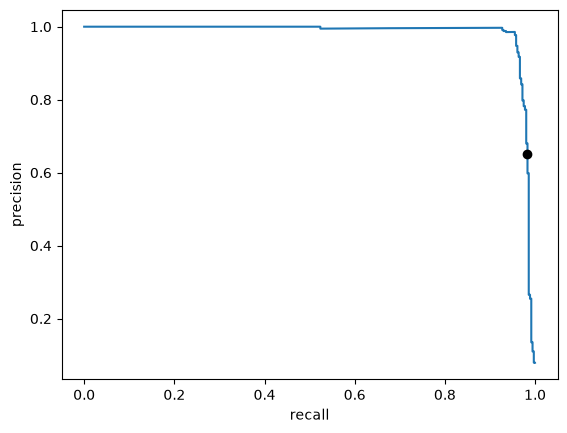

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

precision, recall, _ = precision_recall_curve(ytr, cv_probabilities)
flagged = cv_probabilities > best_threshold
op_precision = ytr[flagged].mean()
op_recall = flagged[ytr == 1].mean()
print(f"average precision (area under the curve): {average_precision_score(ytr, cv_probabilities):.3f}")
print(f"operating point at {best_threshold}: precision {op_precision:.1%}, recall {op_recall:.1%}")

plt.plot(recall, precision)
plt.scatter([op_recall], [op_precision], color="black", zorder=3)
plt.xlabel("recall")
plt.ylabel("precision")
plt.show()

- `precision_recall_curve` (Chapter 39, section 39.2) sweeps every threshold and returns the precision and recall at each; `_` discards the thresholds themselves.
- `ytr[flagged].mean()` is the share of flagged parts that really are defective, the precision; `flagged[ytr == 1].mean()` is the share of real defects that were flagged, the recall.
- `plt.plot` draws the curve and `plt.scatter` marks the operating point; `color="black"` makes the dot stand out from the blue line, and `zorder=3` draws it on top.

![A precision-recall curve that stays near a precision of 1 until recall passes about 0.95, then falls steeply, with the operating point at threshold 0.01 marked on the steep part](figures/fig53-5-pr-curve.svg)

*Figure 53.5 — The defect model's precision-recall curve on the training parts' out-of-fold predictions, with the chosen operating point.*

The curve makes the trade-off visible in a way the table can't: it shows how much recall each false alarm buys, and where the curve turns steep. The cost-chosen point sits on the steep part: it gives up precision to catch the last few defects, because a miss costs a hundred times a false alarm. Report the **area under the precision-recall curve** (average precision) rather than ROC-AUC for rare classes, because ROC-AUC flatters a model when negatives dominate (Chapter 39, section 39.2).

**9.** Uses `cv_probabilities` and `ytr` from section 53.6.

In [45]:
for miss_cost in (4000, 12000):
    rows = []
    for threshold in (0.5, 0.3, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002):
        tn, fp, fn, tp = confusion_matrix(ytr, cv_probabilities > threshold).ravel()
        rows.append((fn * miss_cost + fp * ALARM_COST, threshold, fp))
    cost, threshold, alarms = min(rows)
    print(f"a miss costs {miss_cost:>6,}: best threshold {threshold:<6} total cost {cost:>7,} "
          f"with {alarms} re-inspections per {len(ytr):,} parts")

a miss costs  4,000: best threshold 0.01   total cost  31,560 with 189 re-inspections per 4,500 parts
a miss costs 12,000: best threshold 0.005  total cost  72,040 with 301 re-inspections per 4,500 parts


- `rows` collects (cost, threshold, false alarms) for each threshold; `min(rows)` compares the tuples by their first item, the cost, so it returns the cheapest row, and the next line unpacks its three values.

At ₹4,000 a miss the answer is section 53.6's: 0.01. At ₹12,000 the threshold moves down to 0.005, which catches one more defect in the out-of-fold predictions (6 missed become 5) at the price of 112 more false alarms: re-inspections rise from 189 to 301 per 4,500 parts, from about 4% to about 7% of everything the line makes. That is the inspector's workload going up by more than half, which is the conversation to have with the plant manager before the contract is signed: a dearer miss buys more caution, and caution is paid for in inspection hours.

**10.** Uses `images`, `test_idx`, `features`, `model`, `probabilities`, `yte` and `best_threshold`. Only the 1,500 test images are brightened, so it takes about 15 seconds.

In [46]:
brightened = np.clip(images[test_idx] * 1.1, 0, 1)
X_bright = np.stack([features(image) for image in brightened])

for name, p in (("original", probabilities), ("10% brighter", model.predict_proba(X_bright)[:, 1])):
    tn, fp, fn, tp = confusion_matrix(yte, p > best_threshold).ravel()
    print(f"{name:<13} recall {tp / (tp + fn):>6.1%}  false alarms {fp:>3}")

original      recall  97.5%  false alarms  46
10% brighter  recall  95.8%  false alarms 117


- `np.clip(images[test_idx] * 1.1, 0, 1)` makes every test pixel 10% brighter, then caps values at 1 (and floors them at 0) so the brightened pixels stay valid.
- `features` is section 53.6's function, so the brightened images get exactly the same treatment as the originals.

A 10% brightness change is nothing to a human inspector, and it costs the model two of its 116 catches (recall 97.5% → 95.8%) while multiplying false alarms by about two and a half, from 46 to 117. That is the night-shift story in one experiment, and it's the test to run *before* deployment, not after a customer return. The fixes are augmentation during training and an input check in production (Chapter 56).

**11.** Design ideas that work: a **diagonal** edge detector for scratches that run at 45°, a **larger blob** kernel (5×5) that matches the size of a void better than a 3×3, or a **local variance** feature (the standard deviation within each 5×5 block), which is high wherever the surface isn't smooth. Add one, retrain, and report recall and false alarms before and after on the same split. If a kernel adds nothing, say so: negative results are results, and a model with three useful filters is better than one with six of which three are noise.

**12.** Uses `Xtr` and `ytr`. For a yes/no target, the output gets a sigmoid and the loss is log loss, so the backward pass starts from (prediction − truth), averaged over the 500 parts (section 53.2); the hidden layer has 16 ReLU neurons, started with He initialization (section 53.3).

In [47]:
X500, y500 = Xtr[:500].astype(float), ytr[:500].astype(float)
rng = np.random.default_rng(53)
W1 = rng.normal(0, np.sqrt(2 / 108), (108, 16)); b1 = np.zeros(16)
W2 = rng.normal(0, np.sqrt(2 / 16), 16); b2 = 0.0

for step in range(301):
    z1 = X500 @ W1 + b1; a1 = np.maximum(0, z1)                  # forward pass
    p = 1 / (1 + np.exp(-(a1 @ W2 + b2)))
    loss = -np.mean(y500 * np.log(p) + (1 - y500) * np.log(1 - p))
    dz2 = (p - y500) / len(y500)                                  # backward pass
    dW2 = a1.T @ dz2; db2 = dz2.sum()
    dz1 = np.outer(dz2, W2) * (z1 > 0)
    dW1 = X500.T @ dz1; db1 = dz1.sum(axis=0)
    W1 -= 0.5 * dW1; b1 -= 0.5 * db1; W2 -= 0.5 * dW2; b2 -= 0.5 * db2   # update
    if step % 50 == 0:
        print(f"step {step:>3}: log loss {loss:.4f}")

library = MLPClassifier(hidden_layer_sizes=(16,), max_iter=300, random_state=53).fit(X500, y500)
print(f"scikit-learn after {library.n_iter_} epochs: log loss {library.loss_:.4f}")

step   0: log loss 0.5939
step  50: log loss 0.2463
step 100: log loss 0.1966
step 150: log loss 0.1671
step 200: log loss 0.1403
step 250: log loss 0.1146
step 300: log loss 0.0700


scikit-learn after 300 epochs: log loss 0.1090


- The forward pass is section 53.2's, for all 500 parts at once, with a sigmoid on the output.
- `dz2 = (p - y500) / len(y500)` is the log-loss starting point, averaged; `a1.T @ dz2` adds up each hidden neuron's blame over the 500 parts (`.T` transposes, section 53.7).
- `np.outer(dz2, W2) * (z1 > 0)` passes the blame back through the output weights and ReLU, one row per part, and `X500.T @ dz1` turns it into the gradient for `W1`.
- Each update is section 53.2's, with a learning rate of 0.5. `step % 50 == 0` prints every 50th step.
- `library.loss_` includes scikit-learn's small weight-decay penalty (`alpha`), so it isn't exactly log loss.

Both curves have the same shape, a fast fall and then a long, slow flattening, but not the same numbers: the two start from different random weights, the hand loop steps on all 500 parts at once with a fixed learning rate while scikit-learn uses Adam on mini-batches of 200, and scikit-learn adds the weight-decay penalty. A lower *training* loss on 500 parts is not a better model: neither number says anything about new parts. The purpose of the exercise is to see that "training" is that loop and nothing else; the purpose of using a library afterwards is that the library's version is faster, better tuned, and already debugged.

**13.** Uses section 53.7's `embeddings`, `W_query`, `W_key`, `W_value`, `softmax` and `tokens`.

In [48]:
W_value_big = W_value.copy()
W_value_big[2] = [3.0, 3.0]                      # "was" now carries a large value vector
Q, K = embeddings @ W_query, embeddings @ W_key
weights_again = np.array([softmax(row) for row in (Q @ K.T) / np.sqrt(2)])
for name, W in (("original", W_value), ("big 'was'", W_value_big)):
    out = weights_again @ (embeddings @ W)
    print(f"{name:<10} outputs: {np.round(out, 3).tolist()}")

original   outputs: [[0.454, 0.262], [0.477, 0.264], [0.44, 0.292], [0.526, 0.274]]
big 'was'  outputs: [[1.068, 0.876], [1.062, 0.85], [1.129, 0.981], [1.065, 0.813]]


- `Q, K = ...` recomputes section 53.7's queries and keys, and `weights_again` its attention weights, in one line each; `out = weights_again @ (embeddings @ W)` blends the value vectors for each version of `W_value`.
- `W_value_big[2] = [3.0, 3.0]` replaces the value row for *was* (the third token), leaving the query and key matrices alone, so the attention weights are exactly the ones section 53.7 printed.

Changing `W_value` changes the *outputs* while leaving the attention weights untouched, because weights come from Q and K only. Every token's output moves towards [3, 3] in proportion to the weight it already gave *was*, from about 0.19 for *cracked* to about 0.24 for *was* itself. That is the division of labor worth remembering: **queries and keys decide who is listened to; values decide what is heard.** A token nobody attends to can carry any value it likes without affecting the result.

**14.** Uses `model`, `Xte`, `yte` and `best_threshold`.

In [49]:
def quantize_bits(matrix, bits):
    limit = 2 ** (bits - 1) - 1
    scale = np.abs(matrix).max() / limit
    return np.round(matrix / scale).clip(-limit - 1, limit).astype(np.float32) * scale

original = [c.copy() for c in model.coefs_]
baseline = model.predict_proba(Xte)[:, 1]
for bits in (8, 4):
    model.coefs_ = [quantize_bits(c, bits) for c in original]
    changed = model.predict_proba(Xte)[:, 1]
    flips = int(((baseline > best_threshold) != (changed > best_threshold)).sum())
    print(f"{bits}-bit: largest probability change {np.abs(baseline - changed).max():.4f}, "
          f"decisions flipped {flips} of {len(yte):,}, "
          f"memory {sum(c.size for c in original) * bits // 8:,} bytes")
model.coefs_ = original

8-bit: largest probability change 0.0300, decisions flipped 7 of 1,500, memory 5,232 bytes
4-bit: largest probability change 0.4221, decisions flipped 24 of 1,500, memory 2,616 bytes


- `quantize_bits` is section 53.9's `quantize` with the number of bits as a setting. `original` keeps copies of the real weights and `baseline` their probabilities; the loop swaps in each rounded version, and the last line puts the real weights back.
- `limit` is the largest integer the bits can hold: 127 for 8 bits, 7 for 4 bits. `.clip(-limit - 1, limit)` keeps every rounded value inside the range (−8 to 7 for 4 bits).
- `* bits // 8` converts the count of numbers to bytes: 8 bits are one byte, 4 bits half a byte.

Four-bit quantization halves the memory again and costs more decisions. For a small model on a laptop that trade is pointless; for a large language model that only fits on your GPU at 4 bits, it's the difference between running and not running, which is why 4-bit inference is common for LLMs and rare for small classifiers.

**15.** Expect an agreement rate in the 80s or low 90s: scratches one pixel wide and faint voids are hard to see at 32×32. Two consequences. First, **the model cannot be more accurate than the labels it learned from**, so a "94% accurate" model trained on 90%-agreement labels is partly fitting noise. Second, **measure label agreement before blaming the model**: if two inspectors disagree on 10% of parts, the project's first deliverable is a clearer definition of a defect, not a network.

**16.** Ask which 99%. Always predicting "good" scores 92%; the section 53.6 model at the default threshold already scores 99.2% accuracy on the test parts and still lets 1 defect in 12 through (10 of 119), and at 99% accuracy up to 15 of every 1,500 parts could be wrong, which could be 15 of the 119 defects: 1 in 8 slipping past while the number sounds excellent. Redirect to the two numbers that matter: *"of the defects we produce, what share must we catch, and how many good parts can we afford to re-inspect?"* Then show the cost table from section 53.6, which converts those into a threshold. Managers accept this quickly, because it's the trade-off they already make with human inspectors.

**17.** Three fixes: (a) **collect night-shift images and retrain**, which addresses the cause; (b) **augment brightness and contrast during training**, which makes the model robust to the next lighting change nobody warned you about; (c) **normalize each image** before it reaches the model (subtract its own mean, divide by its own standard deviation), which removes the global lighting signal entirely. Do (c) first, because it's an hour's work and often fixes most of the gap, then (a) and (b) properly. And add the input-brightness monitor whatever you do, because the fourth lighting condition is already out there.

**18.** Fine-tune a pretrained model (Chapter 43, section 43.7) when your images look at all like natural photographs, when you have hundreds rather than tens of thousands of labeled examples, and when you can afford a GPU for an hour. You need: the labeled images, a framework (PyTorch with torchvision), the pretrained weights, and a validation set you trust. The reason it wins is **transfer**: the pretrained network already knows edges, textures, and shapes from millions of images, so your few hundred examples only have to teach it the last step. Train from scratch only when your images are nothing like natural photographs (X-rays, spectrograms, this chapter's synthetic lids) *and* you have the data volume to support it.

---

## Where this leads

- **Chapter 54, Generative AI & Large Language Models,** takes section 53.7's attention and scales it: tokens, context windows, sampling, prompting, embeddings, and fine-tuning.
- **Chapter 55, Building AI Applications: RAG, Agents & Evaluation,** puts a model behind a product: retrieval, tools, evaluation, and guardrails.
- **Chapter 56, MLOps: Making Models Survive Production,** is what happens to the defect model after the trial: serving, monitoring, drift, and retraining. (**MLOps**, short for machine-learning operations, is the work of keeping models running, and right, in production.)
- **Chapter 37, Supervised Learning Algorithms,** is the gradient boosting that beats networks on tables.
- **Chapter 39, Evaluation, Tuning, Interpretation & Honesty,** is the evaluation vocabulary this chapter leaned on: confusion matrices, precision and recall, thresholds by cost, and model cards.
- **Chapter 33, The Computer Science You Actually Need,** explains the O(n²) that limits context windows.
- **Chapter 64, Security, Privacy, Governance & Responsible AI,** covers explainability, bias, and the model card's place in governance.
- **Chapter 74, Machine Learning Question Bank,** has the interview questions on when deep learning is worth it and how to judge a model's claims (Q74-035, Q74-036).